## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from itertools import combinations

# ML
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)
from collections import Counter

# Config
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Imports réussis")

/home/aboussif/.local/lib/python3.11/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


✅ Imports réussis


# Data Loading and Exploration

We load the two datasets:
- **Positives**: known interactions (experimentally validated binders)
- **Negatives**: non-interactions (design failures)

We then merge and clean the data.


In [2]:
# Chemins des données
POS_PATH = Path("../src/data/positive_labeled_dataset_dG_SASA.csv")
NEG_PATH = Path("../src/data/negative_labeled_dataset_dG_SASA.csv")

# Charger
df_pos = pd.read_csv(POS_PATH)
df_neg = pd.read_csv(NEG_PATH)

# Assigner labels
df_pos["label"] = 1  # binder
df_neg["label"] = 0  # non-binder

# Fusionner
df = pd.concat([df_pos, df_neg], ignore_index=True)
df = df.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"✅ Dataset fusionné")
print(f"   Positifs (binders):     {(df['label']==1).sum()}")
print(f"   Négatifs (non-binders): {(df['label']==0).sum()}")
print(f"   Total:                  {len(df)}")
print(f"\n   Shape: {df.shape}")
print(f"\n   Colonnes:\n   {df.columns.tolist()}")

✅ Dataset fusionné
   Positifs (binders):     195
   Négatifs (non-binders): 200
   Total:                  395

   Shape: (395, 10)

   Colonnes:
   ['id', 'ipsae', 'pdockq2', 'prodigy_kd', 'ipTM+pTM', 'dG_SASA_ratio', 'prodigy_dg_internal', 'ipTM', 'dG_rosetta', 'label']


In [3]:
df["pKd"] = -np.log10(df["prodigy_kd"] + 1e-12)
# Nettoyer les colonnes numériques (virgule -> point)
FEATURE_COLS = [
    "ipsae", "pdockq2", "pKd", "ipTM+pTM", 
    "dG_SASA_ratio", "prodigy_dg_internal", "ipTM", "dG_rosetta"
]

for col in FEATURE_COLS:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .replace(["nan", "NaN", ""], np.nan)
        .astype(float)
    )

# Enlever les NaN
df_clean = df.dropna(subset=FEATURE_COLS + ["label"]).copy()

X = df_clean[FEATURE_COLS].values
y = df_clean["label"].values

print(f"   Shape finale: {X.shape}")
print(f"   Features: {len(FEATURE_COLS)}")
print(f"   Exemples valides: {len(df_clean)}")

   Shape finale: (391, 8)
   Features: 8
   Exemples valides: 391


In [4]:
# Statistiques descriptives
print("\n=== Statistiques Descriptives ===")
print(df_clean[FEATURE_COLS + ["label"]].describe())

# Répartition par classe
print("\n=== Distribution des classes ===")
for i, col in enumerate(FEATURE_COLS):
    pos_mean = df_clean[df_clean["label"]==1][col].mean()
    neg_mean = df_clean[df_clean["label"]==0][col].mean()
    print(f"{col:20s} | Pos: {pos_mean:8.3f} | Neg: {neg_mean:8.3f}")


=== Statistiques Descriptives ===
            ipsae     pdockq2         pKd    ipTM+pTM  dG_SASA_ratio  \
count  391.000000  391.000000  391.000000  391.000000     391.000000   
mean     0.372130    0.333323    7.586138    0.577528       2.035089   
std      0.398156    0.325243    2.282037    0.297259       3.084827   
min      0.000000    0.000000    2.345551    0.165925      -0.046140   
25%      0.000000    0.009300    5.930251    0.277246       0.001084   
50%      0.066708    0.167900    7.281076    0.477517       0.552769   
75%      0.828210    0.677300    9.187665    0.901302       2.944248   
max      0.947993    0.839900   12.000000    0.965239      20.022456   

       prodigy_dg_internal        ipTM    dG_rosetta       label  
count           391.000000  391.000000    391.000000  391.000000  
mean            -10.687045    0.532405   3222.184343    0.496164  
std               4.068699    0.337230   5400.930289    0.500626  
min             -37.333412    0.083555   -245.31

## TRAIN/TEST SPLIT

**Avoid any data leakage**

**Before any model evaluation**:
- Split Train/Validation/Test in 70/10/20 with stratification
- All model selection and feature engineering is performed **only** on the training set
- The test set is completely set aside and **never** used for:
  - univariate feature evaluation
  - greedy feature selection
  - interaction feature generation or evaluation
- Final evaluation is performed **only** on the test set, using models trained on the train set


In [5]:
# TRAIN/VALIDATION/TEST SPLIT - STRATIFIED, 70/10/20
from sklearn.model_selection import train_test_split

# First split: 80% train+val / 20% test
# Keep track of indices
temp_indices, test_indices = train_test_split(
    np.arange(len(X)), 
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

X_temp = X[temp_indices]
y_temp = y[temp_indices]
X_test = X[test_indices]
y_test = y[test_indices]

# Second split: split the 80% into 70% train / 10% val
# 10/80 = 0.125
train_indices_relative, val_indices_relative = train_test_split(
    np.arange(len(X_temp)), 
    test_size=0.125,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# Convert back to original indices in df_clean
train_indices = temp_indices[train_indices_relative]
val_indices = temp_indices[val_indices_relative]

X_train = X[train_indices]
y_train = y[train_indices]
X_val = X[val_indices]
y_val = y[val_indices]

print("TRAIN/VALIDATION/TEST SPLIT (Stratified 70/10/20)")
print(f"\nTRAIN SET ({len(X_train)} samples - 70%):")
print(f"   Positives (label=1): {(y_train==1).sum()}")
print(f"   Negatives (label=0): {(y_train==0).sum()}")
print(f"   Ratio: {(y_train==1).sum() / len(y_train) * 100:.1f}% binders")

print(f"\nVALIDATION SET ({len(X_val)} samples - 10%):")
print(f"   Positives (label=1): {(y_val==1).sum()}")
print(f"   Negatives (label=0): {(y_val==0).sum()}")
print(f"   Ratio: {(y_val==1).sum() / len(y_val) * 100:.1f}% binders")

print(f"\nTEST SET ({len(X_test)} samples - 20%):")
print(f"   Positives (label=1): {(y_test==1).sum()}")
print(f"   Negatives (label=0): {(y_test==0).sum()}")
print(f"   Ratio: {(y_test==1).sum() / len(y_test) * 100:.1f}% binders")

print(f"\n✓ Indices tracked:")
print(f"  - train_indices: {len(train_indices)} samples")
print(f"  - val_indices: {len(val_indices)} samples")
print(f"  - test_indices: {len(test_indices)} samples")
print(f"  - No overlap: {len(set(train_indices) & set(val_indices) & set(test_indices)) == 0}")

print(f"\n✓ Validation set is used for:")
print(f"  - Feature selection")
print(f"  - Model training/hyperparameter tuning")
print(f"✓ Test set is held-out and will ONLY be used for final evaluation")


TRAIN/VALIDATION/TEST SPLIT (Stratified 70/10/20)

TRAIN SET (273 samples - 70%):
   Positives (label=1): 136
   Negatives (label=0): 137
   Ratio: 49.8% binders

VALIDATION SET (39 samples - 10%):
   Positives (label=1): 19
   Negatives (label=0): 20
   Ratio: 48.7% binders

TEST SET (79 samples - 20%):
   Positives (label=1): 39
   Negatives (label=0): 40
   Ratio: 49.4% binders

✓ Indices tracked:
  - train_indices: 273 samples
  - val_indices: 39 samples
  - test_indices: 79 samples
  - No overlap: True

✓ Validation set is used for:
  - Feature selection
  - Model training/hyperparameter tuning
✓ Test set is held-out and will ONLY be used for final evaluation


---
# EXPLORATORY DATA ANALYSIS (on TRAIN set only)

- Feature distributions (histograms)
- Feature correlations (heatmap)
- Outliers and missing patterns

In [6]:
# Create DataFrames for EDA using the true split indices
df_train = df_clean.iloc[train_indices].copy()
df_val = df_clean.iloc[val_indices].copy()
df_test = df_clean.iloc[test_indices].copy()

print(f"✅ EDA DataFrames created using TRUE split indices")
print(f"   df_train shape: {df_train.shape}")
print(f"   df_val shape: {df_val.shape}")
print(f"   df_test shape: {df_test.shape}")


✅ EDA DataFrames created using TRUE split indices
   df_train shape: (273, 11)
   df_val shape: (39, 11)
   df_test shape: (79, 11)


In [7]:
# Descriptive statistics by class
print("\n" + "="*70)
print("DESCRIPTIVE STATISTICS (TRAIN SET)")
print("="*70)

print("\n📊 BINDERS (label=1):")
print(df_train[df_train["label"]==1][FEATURE_COLS].describe().round(3))

print("\n📊 NON-BINDERS (label=0):")
print(df_train[df_train["label"]==0][FEATURE_COLS].describe().round(3))

print("\n📊 DIFFERENCE (Binders - Non-binders):")
diff_stats = df_train[df_train["label"]==1][FEATURE_COLS].mean() - df_train[df_train["label"]==0][FEATURE_COLS].mean()
for col, val in diff_stats.items():
    print(f"   {col:20s}: {val:+8.4f}")



DESCRIPTIVE STATISTICS (TRAIN SET)

📊 BINDERS (label=1):
         ipsae  pdockq2      pKd  ipTM+pTM  dG_SASA_ratio  \
count  136.000  136.000  136.000   136.000        136.000   
mean     0.725    0.620    8.515     0.835          0.416   
std      0.265    0.206    2.367     0.180          1.404   
min      0.000    0.000    2.895     0.166         -0.046   
25%      0.684    0.591    6.737     0.841         -0.018   
50%      0.840    0.679    8.304     0.906          0.001   
75%      0.889    0.745   10.606     0.930          0.090   
max      0.948    0.840   12.000     0.965         11.064   

       prodigy_dg_internal     ipTM  dG_rosetta  
count              136.000  136.000     136.000  
mean               -12.361    0.827     905.898  
std                  4.887    0.198    3245.750  
min                -37.333    0.088    -245.318  
25%                -14.483    0.841     -45.776  
50%                -11.321    0.903       3.684  
75%                 -9.185    0.929     29

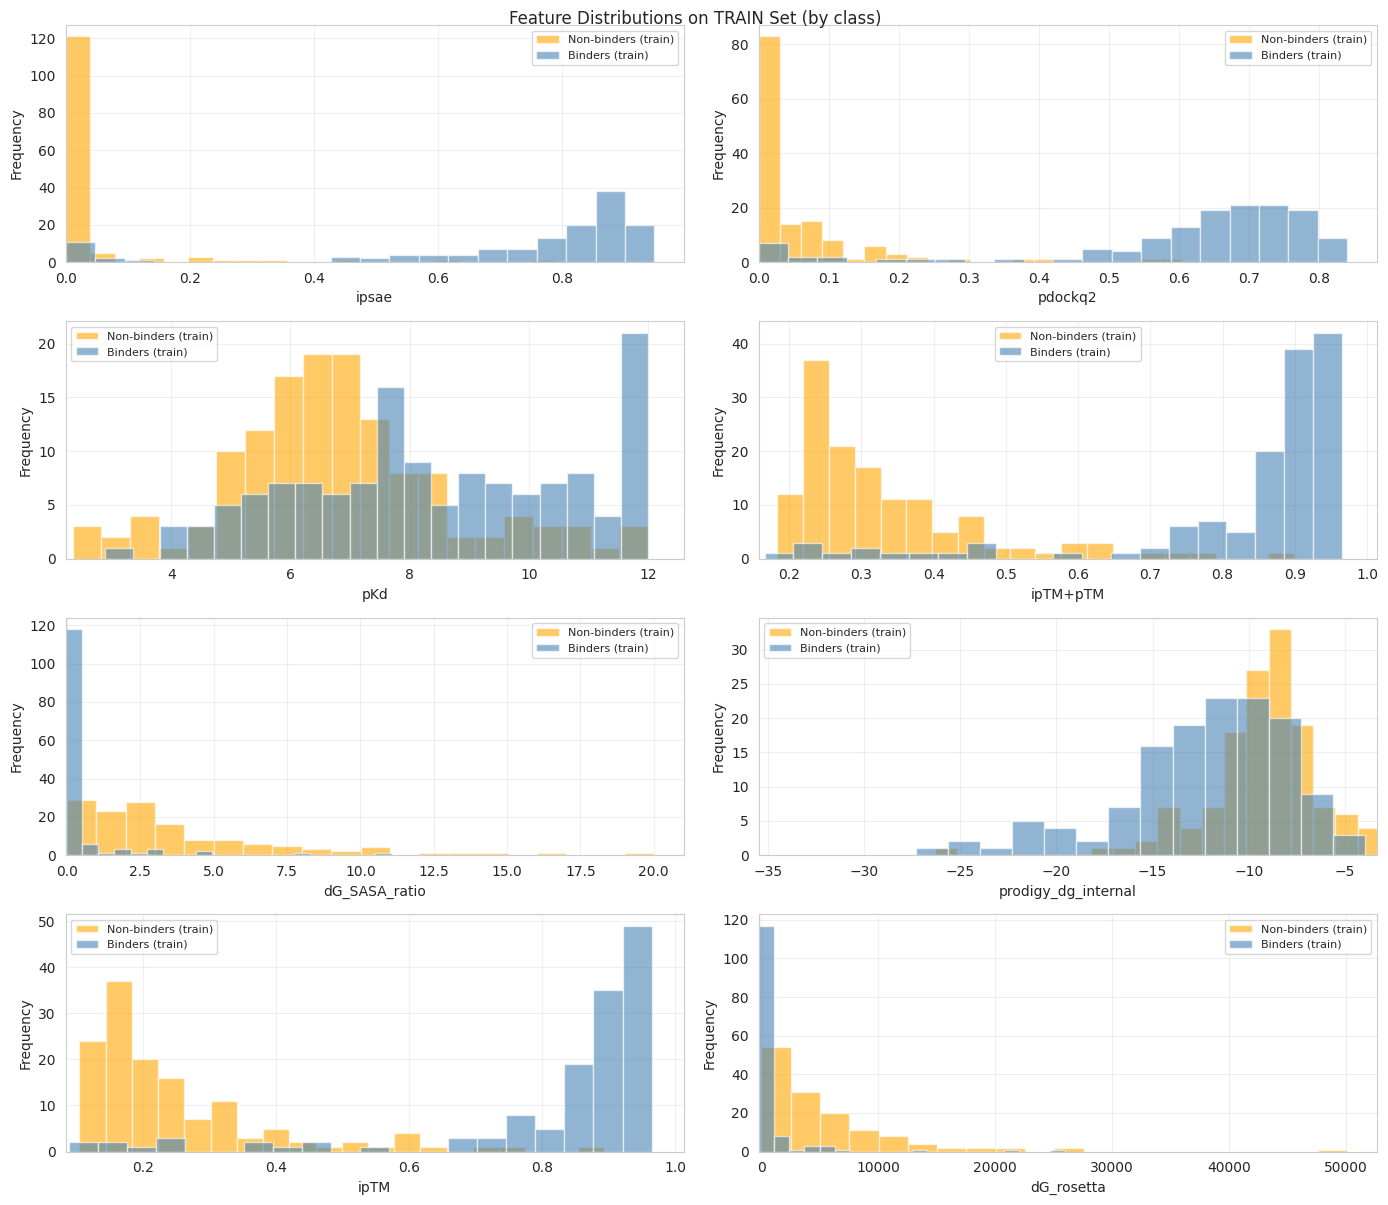

In [8]:
# Distributions and class separation
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.ravel()

# Features nécessitant une échelle log10
log_features = []
delta_features = []


for idx, col in enumerate(FEATURE_COLS):
    ax = axes[idx]
    
    train_pos = df_train[df_train["label"]==1][col].dropna()
    train_neg = df_train[df_train["label"]==0][col].dropna()
    
    
    # Appliquer log10 pour les features d'énergie
    if col in log_features:
        # Prendre valeur absolue + epsilon pour éviter log(0) ou log(négatif)
        train_pos_plot = -np.log10(np.abs(train_pos) + 1e-12)
        train_neg_plot = -np.log10(np.abs(train_neg) + 1e-12)
        xlabel = f"pKd (-log10 {col})"
    elif col in delta_features:
        # Prendre valeur absolue + epsilon pour éviter log(0) ou log(négatif)
        train_pos_plot = np.log10(np.abs(train_pos))
        train_neg_plot = np.log10(np.abs(train_neg))
        xlabel = f"log10 {col}"

    else:
        train_pos_plot = train_pos
        train_neg_plot = train_neg
        xlabel = col

    ax.hist(train_neg_plot, bins=20, alpha=0.6, label='Non-binders (train)', color='orange')
    ax.hist(train_pos_plot, bins=20, alpha=0.6, label='Binders (train)', color='steelblue')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    
    # Centrer sur les données (ajuster limites x et y)
    ax.set_xlim([min(train_pos_plot.min(), train_neg_plot.min()) * 0.95,
                 max(train_pos_plot.max(), train_neg_plot.max()) * 1.05])

plt.tight_layout()
plt.suptitle('Feature Distributions on TRAIN Set (by class)', y=1.00)
plt.show()


            Feature  Lower_bound  Upper_bound  Nb_outliers  Outliers_label_0  Outliers_label_1  Pct_outliers
      dG_SASA_ratio    -4.334427     7.223645           20                18                 2      0.073260
         dG_rosetta -6650.789734 11083.861340           20                17                 3      0.073260
prodigy_dg_internal   -19.409658    -1.396944           14                 1                13      0.051282
              ipsae    -1.259652     2.099420            0                 0                 0      0.000000
            pdockq2    -0.986000     1.678000            0                 0                 0      0.000000
                pKd     1.025897    14.234806            0                 0                 0      0.000000
           ipTM+pTM    -0.661183     1.846550            0                 0                 0      0.000000
               ipTM    -0.881152     1.971572            0                 0                 0      0.000000


/tmp/ipykernel_4184761/3512627769.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_4184761/3512627769.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_4184761/3512627769.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_4184761/3512627769.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_4184761/351262776

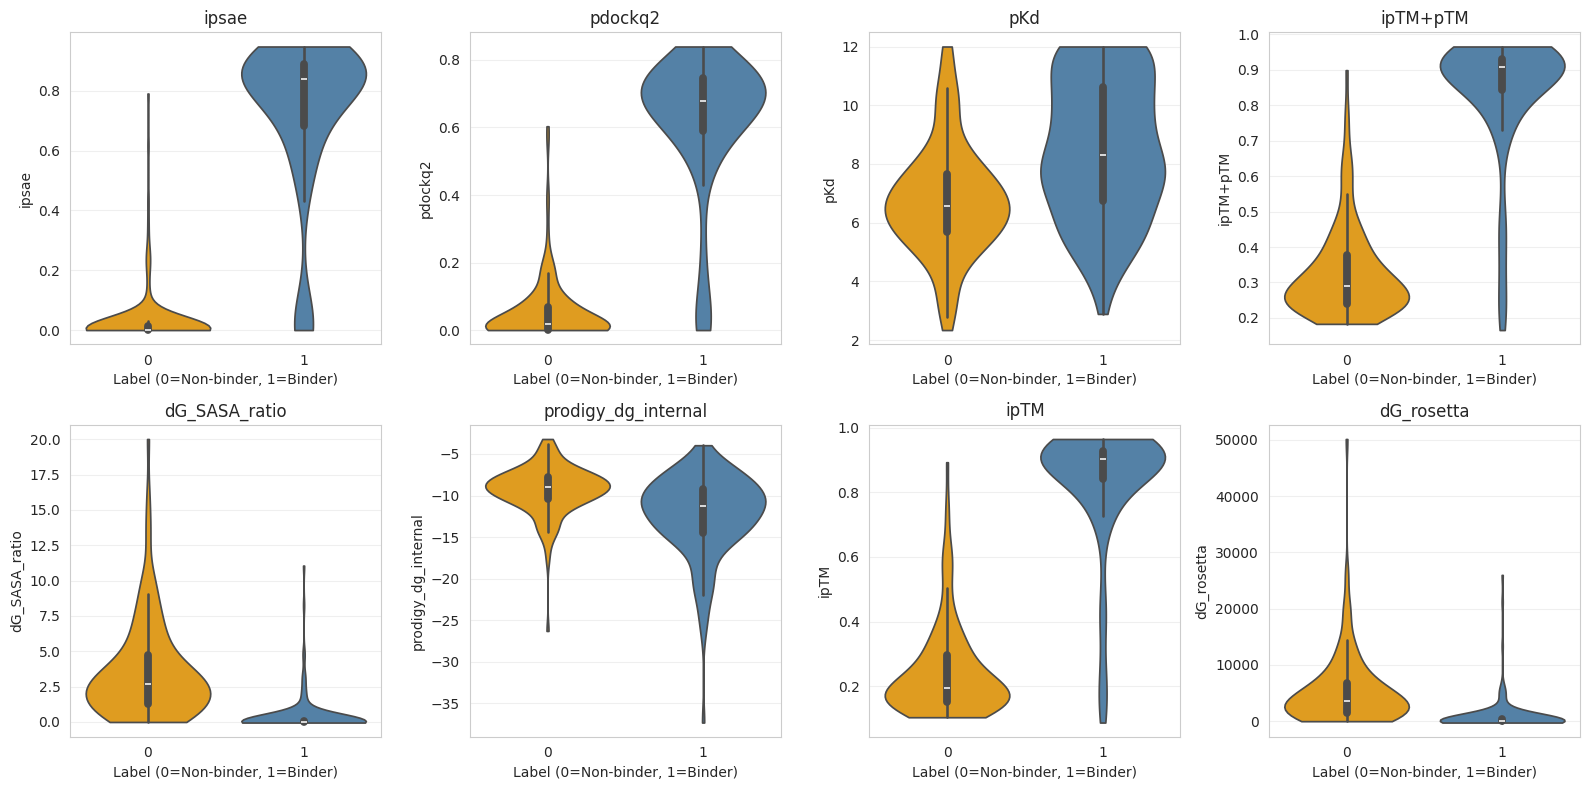

In [10]:
# === Outlier detection (TRAIN only) ===

outlier_info = []

for col in FEATURE_COLS:
    x = df_train[col].dropna()
    
    Q1 = np.percentile(x, 25)
    Q3 = np.percentile(x, 75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Identify outliers
    mask_outliers = (df_train[col] < lower) | (df_train[col] > upper)
    n_outliers = mask_outliers.sum()
    
    # Count outliers by label
    n_outliers_label_0 = ((df_train[col] < lower) | (df_train[col] > upper)) & (df_train['label'] == 0)
    n_outliers_label_1 = ((df_train[col] < lower) | (df_train[col] > upper)) & (df_train['label'] == 1)
    
    outlier_info.append({
        "Feature": col,
        "Lower_bound": lower,
        "Upper_bound": upper,
        "Nb_outliers": n_outliers,
        "Outliers_label_0": n_outliers_label_0.sum(),
        "Outliers_label_1": n_outliers_label_1.sum(),
        "Pct_outliers": n_outliers / len(x)
    })

df_outliers = pd.DataFrame(outlier_info).sort_values("Pct_outliers", ascending=False)
print(df_outliers.to_string(index=False))

# Plot violin plots with split by label for visual inspection
import seaborn as sns
n_cols = 4
n_rows = int(np.ceil(len(FEATURE_COLS) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes = axes.ravel()

for ax, col in zip(axes, FEATURE_COLS):
    # Violin plot with split by label
        # Appliquer log10 pour les features d'énergie
    if col in log_features:
        # Prendre valeur absolue + epsilon pour éviter log(0) ou log(négatif)
        train_pos_plot = -np.log10(np.abs(train_pos))
        train_neg_plot = -np.log10(np.abs(train_neg))
        xlabel = f"pKd (-log10 {col})"
    elif col in delta_features:
        # Prendre valeur absolue + epsilon pour éviter log(0) ou log(négatif)
        train_pos_plot = np.log10(np.abs(train_pos))
        train_neg_plot = np.log10(np.abs(train_neg))
        xlabel = f"log10 {col}"

    else:
        train_pos_plot = train_pos
        train_neg_plot = train_neg
        xlabel = col

    sns.violinplot(
        data=df_train,
        x="label",
        y=col,
        ax=ax,
        palette=["orange", "steelblue"],
        inner="box",  # Shows quartiles and outliers
        cut=0  # Don't extend the density past extreme data points
    )
    ax.set_xlabel("Label (0=Non-binder, 1=Binder)")
    ax.set_ylabel(col)
    ax.set_title(xlabel)
    ax.grid(alpha=0.3, axis='y')

for j in range(len(FEATURE_COLS), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


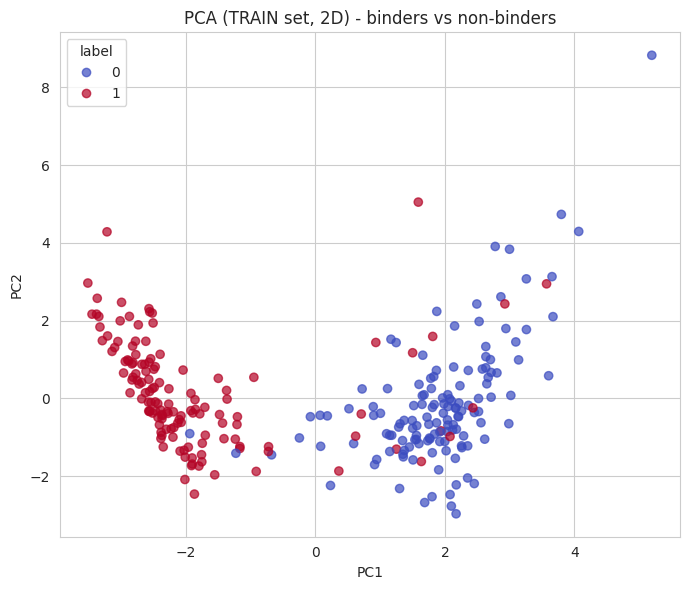

Explained variance ratio: [0.62653954 0.27152258]


In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# optionnel : 
# !pip install umap-learn
# import umap

# On prend uniquement les features, TRAIN set
X_train_eda = df_train[FEATURE_COLS].values
y_train_eda = df_train["label"].values

# Standardisation
scaler_eda = StandardScaler()
X_train_scaled = scaler_eda.fit_transform(X_train_eda)

# PCA 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_train_scaled)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y_train_eda,
    cmap="coolwarm",
    alpha=0.7
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA (TRAIN set, 2D) - binders vs non-binders")
plt.legend(*scatter.legend_elements(), title="label")
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


In [12]:
from scipy.stats import mannwhitneyu
import statsmodels.stats.multitest as smm 

results = []

for col in FEATURE_COLS:
    pos = df_train[df_train["label"] == 1][col].dropna().values
    neg = df_train[df_train["label"] == 0][col].dropna().values
    
    if len(pos) == 0 or len(neg) == 0:
        continue  # sécurité
    
    # Mann–Whitney U test (two-sided)
    u_stat, p_val = mannwhitneyu(pos, neg, alternative="two-sided")
    
    # Effet de taille : rank-biserial correlation
    n1, n2 = len(pos), len(neg)
    rbc = 2 * u_stat / (n1 * n2) - 1  # entre -1 et 1
    
    results.append({
        "Feature": col,
        "U_stat": u_stat,
        "p_value": p_val,
        "Rank-biserial_effect_size": rbc,
        "Mean_pos": pos.mean(),
        "Mean_neg": neg.mean(),
        "Median_pos": np.median(pos),
        "Median_neg": np.median(neg),
    })

df_stats = pd.DataFrame(results)

# Correction de Benjamini–Hochberg (FDR)
pvals = df_stats["p_value"].values
rejected, pvals_corr, _, _ = smm.multipletests(pvals, alpha=0.05, method="fdr_bh")
df_stats["p_value_FDR"] = pvals_corr
df_stats["Significant_FDR_0.05"] = rejected

# Trier par p-value corrigée ou effet de taille absolu
df_stats = df_stats.sort_values("p_value_FDR")

print("=== Mann–Whitney U tests (TRAIN set, 1 vs 0) ===")
print(df_stats.to_string(index=False))


=== Mann–Whitney U tests (TRAIN set, 1 vs 0) ===
            Feature  U_stat      p_value  Rank-biserial_effect_size   Mean_pos    Mean_neg  Median_pos  Median_neg  p_value_FDR  Significant_FDR_0.05
              ipsae 17789.0 9.991338e-40                   0.909511   0.725498    0.032704    0.840126    0.000000 7.993070e-39                  True
            pdockq2 17802.5 4.687875e-39                   0.910960   0.619753    0.053894    0.679000    0.016700 1.875150e-38                  True
               ipTM 17786.0 1.487555e-38                   0.909188   0.826779    0.246593    0.902612    0.195424 3.966814e-38                  True
           ipTM+pTM 17709.0 6.904086e-38                   0.900923   0.834662    0.328316    0.906312    0.290451 1.380817e-37                  True
      dG_SASA_ratio  1444.0 1.554666e-33                  -0.844998   0.415640    3.599114    0.000951    2.695219 2.487466e-33                  True
         dG_rosetta  1897.0 5.654009e-30           

In [13]:
def p_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

df_stats["Signif_stars_FDR"] = df_stats["p_value_FDR"].apply(p_to_stars)

print("=== Mann–Whitney U tests (TRAIN set, 1 vs 0, with FDR) ===")
print(df_stats.to_string(index=False))


=== Mann–Whitney U tests (TRAIN set, 1 vs 0, with FDR) ===
            Feature  U_stat      p_value  Rank-biserial_effect_size   Mean_pos    Mean_neg  Median_pos  Median_neg  p_value_FDR  Significant_FDR_0.05 Signif_stars_FDR
              ipsae 17789.0 9.991338e-40                   0.909511   0.725498    0.032704    0.840126    0.000000 7.993070e-39                  True              ***
            pdockq2 17802.5 4.687875e-39                   0.910960   0.619753    0.053894    0.679000    0.016700 1.875150e-38                  True              ***
               ipTM 17786.0 1.487555e-38                   0.909188   0.826779    0.246593    0.902612    0.195424 3.966814e-38                  True              ***
           ipTM+pTM 17709.0 6.904086e-38                   0.900923   0.834662    0.328316    0.906312    0.290451 1.380817e-37                  True              ***
      dG_SASA_ratio  1444.0 1.554666e-33                  -0.844998   0.415640    3.599114    0.000951    

/tmp/ipykernel_4184761/3133870710.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_4184761/3133870710.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_4184761/3133870710.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_4184761/3133870710.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_4184761/313387071

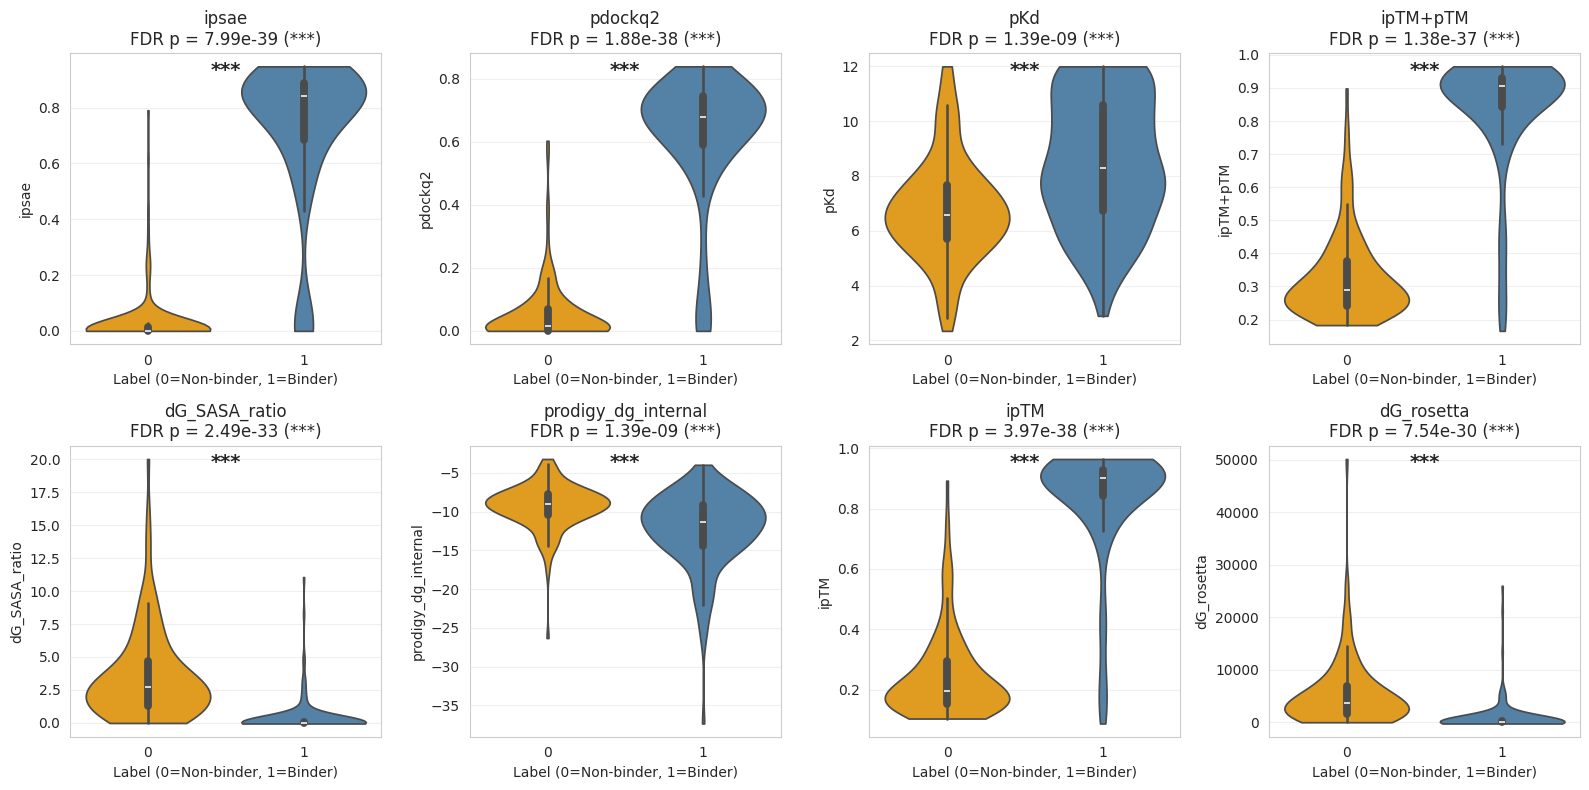

In [14]:
# On prépare un dict pour retrouver rapidement les stats d'une feature
stats_by_feat = df_stats.set_index("Feature")

n_features = len(FEATURE_COLS)
n_cols = 4  # adapte si besoin
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows), squeeze=False)
axes = axes.ravel()

for ax, col in zip(axes, FEATURE_COLS):
    # Violin plot binders vs non-binders sur TRAIN
    sns.violinplot(
        data=df_train,
        x="label",
        y=col,
        ax=ax,
        palette=["orange", "steelblue"],
        inner="box",  # Shows quartiles and outliers
        cut=0  # Don't extend the density past extreme data points
    )
    
    ax.set_xlabel("Label (0=Non-binder, 1=Binder)")
    ax.set_ylabel(col)
    ax.grid(alpha=0.3, axis='y')
    
    # Récupérer p_FDR et étoiles pour cette feature
    if col in stats_by_feat.index:
        p_fdr = stats_by_feat.loc[col, "p_value_FDR"]
        stars = stats_by_feat.loc[col, "Signif_stars_FDR"]
        
        # Titre avec p_FDR
        ax.set_title(f"{col}\nFDR p = {p_fdr:.2e} ({stars})")
        
        # Position de l'annotation
        y_min = df_train[col].min()
        y_max = df_train[col].max()
        y_range = y_max - y_min
        
        # On place les étoiles au-dessus des violin plots
        ax.text(
            0.5,                           # au milieu entre 0 et 1 sur l'axe x
            y_max -  0.05 * y_range,        # un peu au-dessus du max
            stars,
            ha="center",
            va="bottom",
            fontsize=14,
            fontweight="bold"
        )
    else:
        ax.set_title(col + "\n(no stats)")

# Enlever les axes vides si n_features < n_rows * n_cols
for j in range(len(FEATURE_COLS), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [16]:
from sklearn.utils import resample

n_boot = 1000
rng = np.random.default_rng(RANDOM_STATE)

bootstrap_results = []

for col in FEATURE_COLS:
    pos = df_train[df_train["label"] == 1][col].dropna().values
    neg = df_train[df_train["label"] == 0][col].dropna().values
    
    if len(pos) == 0 or len(neg) == 0:
        continue
    
    # Observed statistics
    med_diff_obs = np.median(pos) - np.median(neg)
    
    # rank-biserial effect size
    u_stat, _ = mannwhitneyu(pos, neg, alternative="two-sided")
    rbc_obs = 2 * u_stat / (len(pos)*len(neg)) - 1
    
    # Bootstrap sampling
    med_diffs = []
    rbc_vals = []
    
    for _ in range(n_boot):
        pos_bs = rng.choice(pos, size=len(pos), replace=True)
        neg_bs = rng.choice(neg, size=len(neg), replace=True)
        
        # Median difference
        med_diffs.append(np.median(pos_bs) - np.median(neg_bs))
        
        # Rank-biserial scaled U-stat
        u_bs, _ = mannwhitneyu(pos_bs, neg_bs, alternative="two-sided")
        rbc_vals.append(2 * u_bs / (len(pos_bs)*len(neg_bs)) - 1)
    
    # Confidence intervals
    med_CI = np.percentile(med_diffs, [2.5, 97.5])
    rbc_CI = np.percentile(rbc_vals, [2.5, 97.5])
    
    bootstrap_results.append({
        "Feature": col,
        "Median_diff_obs": med_diff_obs,
        "Median_diff_CI_low": med_CI[0],
        "Median_diff_CI_high": med_CI[1],
        "Rank_biserial_obs": rbc_obs,
        "Rank_biserial_CI_low": rbc_CI[0],
        "Rank_biserial_CI_high": rbc_CI[1],
    })

df_boot = pd.DataFrame(bootstrap_results).sort_values("Median_diff_obs", key=abs, ascending=False)
print(df_boot.to_string(index=False))


            Feature  Median_diff_obs  Median_diff_CI_low  Median_diff_CI_high  Rank_biserial_obs  Rank_biserial_CI_low  Rank_biserial_CI_high
         dG_rosetta     -3609.854174        -4500.877060         -2760.255934          -0.796372             -0.867542              -0.716705
      dG_SASA_ratio        -2.694269           -2.992882            -2.328869          -0.844998             -0.905649              -0.771989
prodigy_dg_internal        -2.377737           -3.547026            -1.463507          -0.424109             -0.545993              -0.302582
                pKd         1.743972            1.070995             2.531866           0.424109              0.298355               0.544010
              ipsae         0.840126            0.803359             0.858851           0.909511              0.855892               0.957655
               ipTM         0.707188            0.678492             0.727918           0.909188              0.851436               0.963292
      

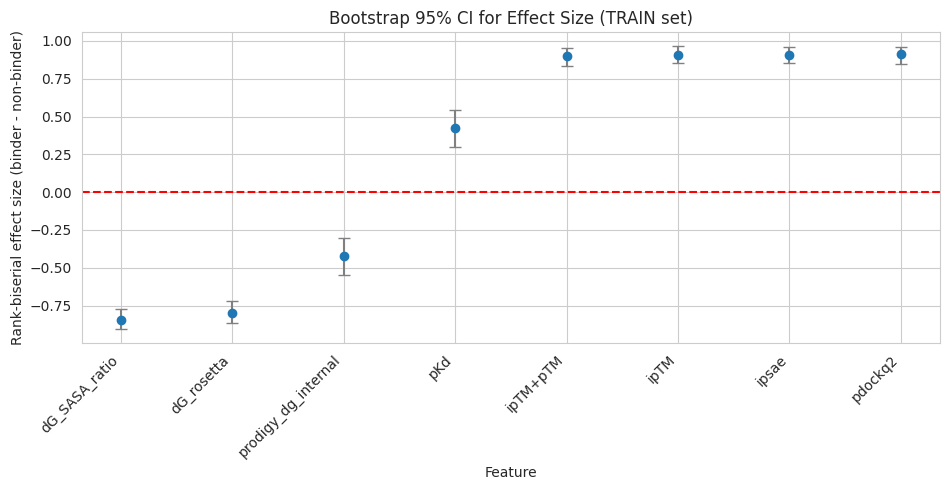

In [17]:
df_boot_effect = df_boot.sort_values("Rank_biserial_obs")

fig, ax = plt.subplots(figsize=(len(df_boot_effect) * 1.2, 5))

ax.errorbar(
    df_boot_effect["Feature"],
    df_boot_effect["Rank_biserial_obs"],
    yerr=[
        df_boot_effect["Rank_biserial_obs"] - df_boot_effect["Rank_biserial_CI_low"],
        df_boot_effect["Rank_biserial_CI_high"] - df_boot_effect["Rank_biserial_obs"]
    ],
    fmt='o',
    ecolor='gray',
    capsize=4
)

ax.axhline(0, color='red', linestyle='--')

ax.set_ylabel("Rank-biserial effect size (binder - non-binder)")
ax.set_xlabel("Feature")
ax.set_title("Bootstrap 95% CI for Effect Size (TRAIN set)")

# Pour éviter le chevauchement des labels
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


### Explanation of Paper Figure 3

The paper (Figure 3A-D) tests **each metric individually** to identify the best binding predictors.

**Paper's logic**:
- For each feature, calculate its ability to separate binders from non-binders
- Use Average Precision (AP) as primary metric (robust to class imbalance ~12% binders in their dataset, here ~50%)
- Also report ROC AUC for comparison
- Identify the best individual predictors

**Our implementation**:
- Univariate training on the full TRAIN set (70% of data)
- Normalization with StandardScaler
- Simple logistic regression for each feature (univariate)
- ROC AUC and AP calculation on VAL for unbiased results


In [18]:
# Univariate evaluation: TRAIN on train set, EVALUATE on val set
univariate_scores = []

for col in FEATURE_COLS:
    x_train_col = X_train[:, FEATURE_COLS.index(col)]
    x_val_col = X_val[:, FEATURE_COLS.index(col)]
    
    # Fit scaler on TRAIN set only
    scaler_tmp = StandardScaler()
    x_train_scaled = scaler_tmp.fit_transform(x_train_col.reshape(-1, 1)).ravel()
    # Transform validation set using train set fitted scaler
    x_val_scaled = scaler_tmp.transform(x_val_col.reshape(-1, 1)).ravel()
    
    # Train univariate logistic regression on TRAIN set
    lr_uni = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE,
    )
    lr_uni.fit(x_train_scaled.reshape(-1, 1), y_train)
    
    # Evaluate on VALIDATION set ONLY
    y_proba_val = lr_uni.predict_proba(x_val_scaled.reshape(-1, 1))[:, 1]
    
    auc = roc_auc_score(y_val, y_proba_val)
    ap = average_precision_score(y_val, y_proba_val)
    
    univariate_scores.append({
        "Feature": col,
        "ROC AUC (VAL)": auc,
        "AP (VAL)": ap,
        "Coefficient": lr_uni.coef_[0][0]
    })

df_univariate = pd.DataFrame(univariate_scores).sort_values("AP (VAL)", ascending=False)
print("\n=== Évaluation Univariée des Features ===")
print("(Trained on TRAIN set, Evaluated on VALIDATION set)")
print(df_univariate.to_string(index=False))


=== Évaluation Univariée des Features ===
(Trained on TRAIN set, Evaluated on VALIDATION set)
            Feature  ROC AUC (VAL)  AP (VAL)  Coefficient
              ipsae       1.000000  1.000000     3.086482
            pdockq2       1.000000  1.000000     3.138372
               ipTM       0.994737  0.994987     2.891754
           ipTM+pTM       0.992105  0.992823     2.838705
      dG_SASA_ratio       0.952632  0.955017    -2.847941
         dG_rosetta       0.950000  0.947115    -2.174955
                pKd       0.555263  0.571313     0.828209
prodigy_dg_internal       0.555263  0.571313    -0.943076


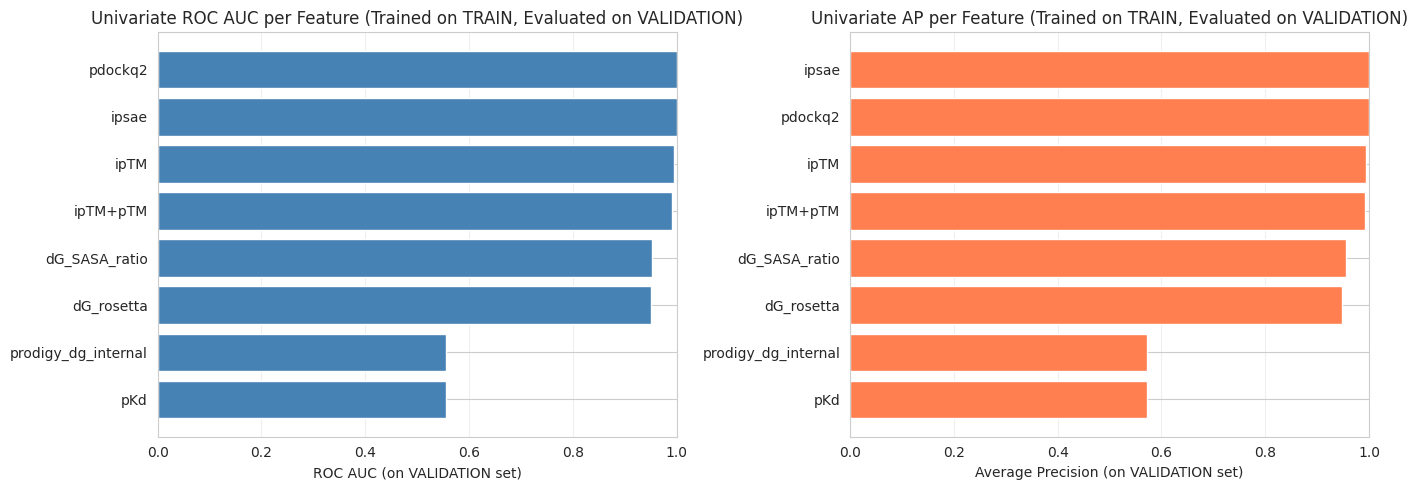


Top feature (on VALIDATION): ipsae (AP=1.0000)


In [19]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC AUC
df_plot = df_univariate.sort_values("ROC AUC (VAL)", ascending=True)
axes[0].barh(df_plot["Feature"], df_plot["ROC AUC (VAL)"], color="steelblue")
axes[0].set_xlabel("ROC AUC (on VALIDATION set)")
axes[0].set_title("Univariate ROC AUC per Feature (Trained on TRAIN, Evaluated on VALIDATION)")
axes[0].grid(alpha=0.3, axis='x')

# Average Precision
df_plot = df_univariate.sort_values("AP (VAL)", ascending=True)
axes[1].barh(df_plot["Feature"], df_plot["AP (VAL)"], color="coral")
axes[1].set_xlabel("Average Precision (on VALIDATION set)")
axes[1].set_title("Univariate AP per Feature (Trained on TRAIN, Evaluated on VALIDATION)")
axes[0].set_xlim(0.0, 1.0)
axes[1].set_xlim(0.0, 1.0)

axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\nTop feature (on VALIDATION): {df_univariate.iloc[0]['Feature']} (AP={df_univariate.iloc[0]['AP (VAL)']:.4f})")

In [20]:
print("\n" + "="*70)
print("ROBUST UNIVARIATE ANALYSIS (CV on TRAIN + Bootstrap on VAL)")
print("="*70)

n_splits = 5
n_boot = 1000
rng = np.random.default_rng(RANDOM_STATE)

univariate_results = []

for col in FEATURE_COLS:
    
    # ---------
    # 1) CV interne sur TRAIN pour stabilité
    # ---------
    auc_cv = []
    ap_cv = []
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    
    for train_idx, test_idx in skf.split(X_train, y_train):
        x_tr = X_train[train_idx][:, FEATURE_COLS.index(col)].reshape(-1, 1)
        y_tr = y_train[train_idx]
        
        x_te = X_train[test_idx][:, FEATURE_COLS.index(col)].reshape(-1, 1)
        y_te = y_train[test_idx]
        
        scaler = StandardScaler()
        x_tr_s = scaler.fit_transform(x_tr)
        x_te_s = scaler.transform(x_te)
        
        lr = LogisticRegression(
            penalty="l1",
            solver="liblinear",
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE
        )
        lr.fit(x_tr_s, y_tr)
        
        y_proba_cv = lr.predict_proba(x_te_s)[:, 1]
        
        auc_cv.append(roc_auc_score(y_te, y_proba_cv))
        ap_cv.append(average_precision_score(y_te, y_proba_cv))
    
    
    # ---------
    # 2) Bootstrap sur VALIDATION
    # ---------
    auc_boot = []
    ap_boot = []
    
    x_train_col = X_train[:, FEATURE_COLS.index(col)].reshape(-1,1)
    x_val_col   = X_val[:, FEATURE_COLS.index(col)].reshape(-1,1)

    scaler = StandardScaler().fit(x_train_col)
    x_train_scaled = scaler.transform(x_train_col)
    x_val_scaled   = scaler.transform(x_val_col)

    lr_final = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE
    )
    lr_final.fit(x_train_scaled, y_train)

    y_proba_val = lr_final.predict_proba(x_val_scaled)[:,1]

    for _ in range(n_boot):
        idx = rng.integers(0, len(y_val), len(y_val))
        auc_boot.append(roc_auc_score(y_val[idx], y_proba_val[idx]))
        ap_boot.append(average_precision_score(y_val[idx], y_proba_val[idx]))

    def ci95(x): return np.percentile(x, [2.5, 95.5])
    
    univariate_results.append({
        "Feature": col,
        "AUC_CV_mean": np.mean(auc_cv),
        "AUC_CV_std": np.std(auc_cv),
        "AUC_VAL": roc_auc_score(y_val, y_proba_val),
        "AUC_VAL_CI_low": ci95(auc_boot)[0],
        "AUC_VAL_CI_high": ci95(auc_boot)[1],
        
        "AP_CV_mean": np.mean(ap_cv),
        "AP_CV_std": np.std(ap_cv),
        "AP_VAL": average_precision_score(y_val, y_proba_val),
        "AP_VAL_CI_low": ci95(ap_boot)[0],
        "AP_VAL_CI_high": ci95(ap_boot)[1],
        
        "Coefficient": lr_final.coef_[0][0],
    })

df_uni = pd.DataFrame(univariate_results).sort_values("AP_VAL", ascending=False)
print(df_uni.to_string(index=False))



ROBUST UNIVARIATE ANALYSIS (CV on TRAIN + Bootstrap on VAL)


            Feature  AUC_CV_mean  AUC_CV_std  AUC_VAL  AUC_VAL_CI_low  AUC_VAL_CI_high  AP_CV_mean  AP_CV_std   AP_VAL  AP_VAL_CI_low  AP_VAL_CI_high  Coefficient
              ipsae     0.951690    0.011064 1.000000        1.000000         1.000000    0.961651   0.008781 1.000000       1.000000        1.000000     3.086482
            pdockq2     0.952846    0.014058 1.000000        1.000000         1.000000    0.965992   0.009180 1.000000       1.000000        1.000000     3.138372
               ipTM     0.952675    0.015303 0.994737        0.973538         1.000000    0.967227   0.012047 0.994987       0.975709        1.000000     2.891754
           ipTM+pTM     0.946286    0.019931 0.992105        0.966643         1.000000    0.963768   0.013352 0.992823       0.967914        1.000000     2.838705
      dG_SASA_ratio     0.923888    0.019860 0.952632        0.884211         0.994709    0.940330   0.020309 0.955017       0.881104        0.995868    -2.847941
         dG_rosetta   

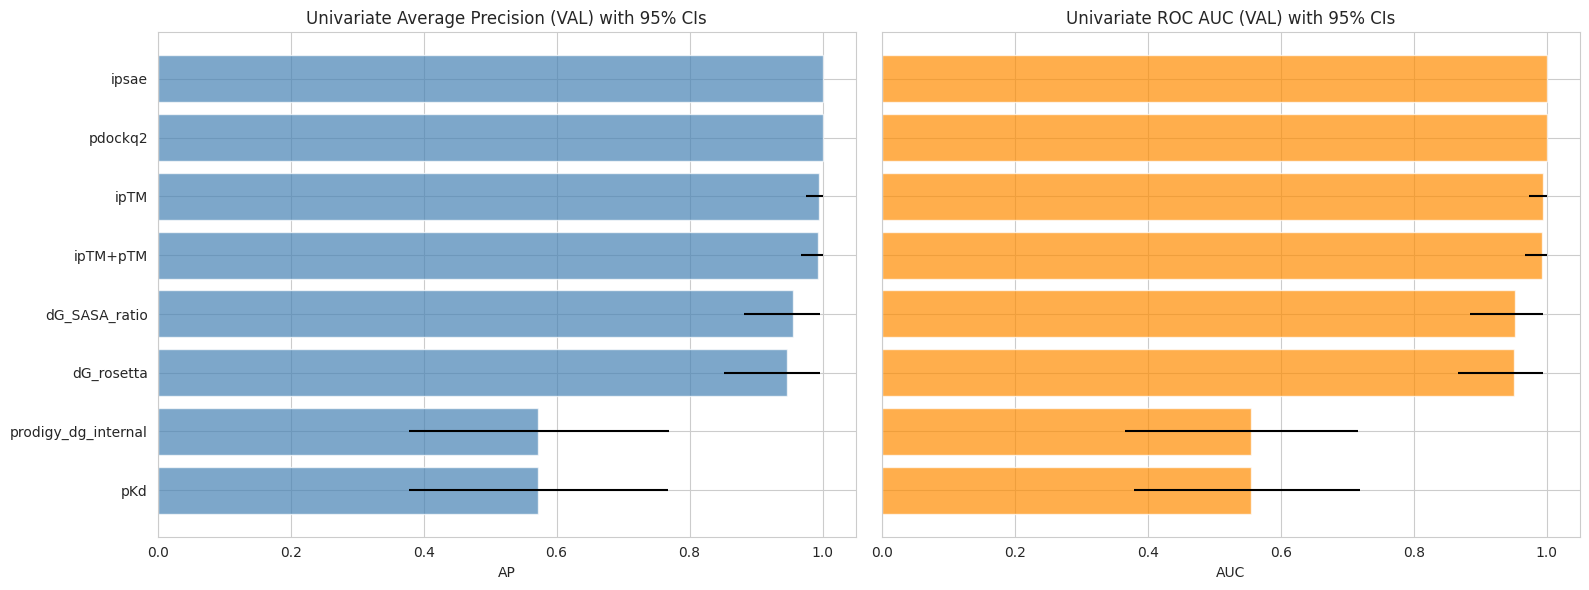

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Tri
df_uni_sorted = df_uni.sort_values("AP_VAL", ascending=True)

# AP
axes[0].barh(df_uni_sorted["Feature"], df_uni_sorted["AP_VAL"], 
             xerr=[df_uni_sorted["AP_VAL"] - df_uni_sorted["AP_VAL_CI_low"],
                   df_uni_sorted["AP_VAL_CI_high"] - df_uni_sorted["AP_VAL"]],
             color="steelblue", alpha=0.7)
axes[0].set_title("Univariate Average Precision (VAL) with 95% CIs")
axes[0].set_xlabel("AP")

# AUC
axes[1].barh(df_uni_sorted["Feature"], df_uni_sorted["AUC_VAL"],
             xerr=[df_uni_sorted["AUC_VAL"] - df_uni_sorted["AUC_VAL_CI_low"],
                   df_uni_sorted["AUC_VAL_CI_high"] - df_uni_sorted["AUC_VAL"]],
             color="darkorange", alpha=0.7)
axes[1].set_title("Univariate ROC AUC (VAL) with 95% CIs")
axes[1].set_xlabel("AUC")

plt.tight_layout()
plt.show()


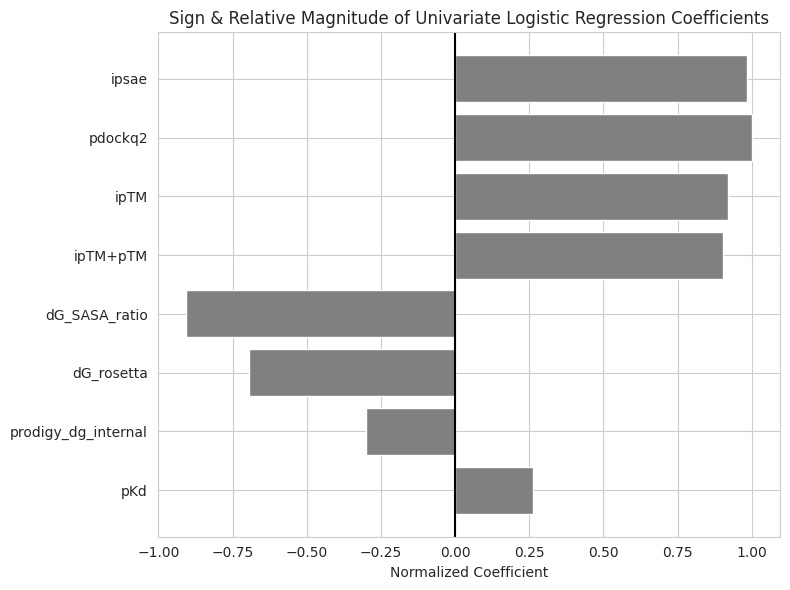

In [22]:
df_coef = df_uni_sorted.copy()
df_coef["Coefficient_norm"] = df_coef["Coefficient"] / df_coef["Coefficient"].abs().max()

plt.figure(figsize=(8, 6))
plt.barh(df_coef["Feature"], df_coef["Coefficient_norm"], color="grey")
plt.axvline(0, color="black")
plt.title("Sign & Relative Magnitude of Univariate Logistic Regression Coefficients")
plt.xlabel("Normalized Coefficient")
plt.tight_layout()
plt.show()


### Explanation of Interaction Features

The paper generates **interaction features** by multiplying features pairwise: $f_i \times f_j$

**Scientific logic**:
- A single metric (ex: AF2 confidence) may not be discriminative enough
- Combining confidence + physics can improve prediction
  - Ex: (high AF2 confidence) × (favorable dG/SASA) = very good binding
  - Ex: (low AF2 confidence) × (anything) = design failure even with good energy
- Some interactions are more predictive than individual features

**Our implementation**:
- Generate all pairwise combinations $f_i \times f_j$ on TRAIN
- Evaluate each product univariately (TRAIN → VAL)
- Keep top 20 interactions by AP
- These interactions become candidates for greedy selection


In [23]:
# Generate interactions (pairwise products) on TRAIN set only
interaction_features_train = {}
interaction_features_val = {}
interaction_features_test = {}
interaction_scores = []

feature_indices = {name: i for i, name in enumerate(FEATURE_COLS)}

for i, j in combinations(range(len(FEATURE_COLS)), 2):
    f1_name = FEATURE_COLS[i]
    f2_name = FEATURE_COLS[j]
    interaction_name = f"{f1_name} × {f2_name}"
    
    # Calculate products on TRAIN and VALIDATION
    x_interaction_train = X_train[:, i] * X_train[:, j]
    x_interaction_val = X_val[:, i] * X_val[:, j]
    x_interaction_test = X_test[:, i] * X_test[:, j]
    interaction_features_train[interaction_name] = x_interaction_train
    interaction_features_val[interaction_name] = x_interaction_val
    interaction_features_test[interaction_name] = x_interaction_test
    
    # Fit scaler on TRAIN set
    scaler_tmp = StandardScaler()
    x_train_scaled = scaler_tmp.fit_transform(x_interaction_train.reshape(-1, 1)).ravel()
    x_val_scaled = scaler_tmp.transform(x_interaction_val.reshape(-1, 1)).ravel()
    # Train on TRAIN, evaluate on VALIDATION ONLY
    lr_inter = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE,
    )
    lr_inter.fit(x_train_scaled.reshape(-1, 1), y_train)
    y_proba_val = lr_inter.predict_proba(x_val_scaled.reshape(-1, 1))[:, 1]
    auc = roc_auc_score(y_val, y_proba_val)
    ap = average_precision_score(y_val, y_proba_val)
    
    interaction_scores.append({
        "Interaction": interaction_name,
        "ROC AUC (VAL)": auc,
        "AP (VAL)": ap
    })

df_interactions = pd.DataFrame(interaction_scores).sort_values("AP (VAL)", ascending=False)

print(f"✅ {len(interaction_features_train)} interactions generated on TRAIN set")
print(f"\n=== Top 20 Interaction Features (evaluated on VALIDATION) ===")
print(df_interactions.head(20).to_string(index=False))

✅ 28 interactions generated on TRAIN set

=== Top 20 Interaction Features (evaluated on VALIDATION) ===
                        Interaction  ROC AUC (VAL)  AP (VAL)
                    ipsae × pdockq2       1.000000  1.000000
                   ipsae × ipTM+pTM       1.000000  1.000000
        ipsae × prodigy_dg_internal       1.000000  1.000000
                        ipsae × pKd       1.000000  1.000000
                      pdockq2 × pKd       1.000000  1.000000
                 pdockq2 × ipTM+pTM       1.000000  1.000000
      pdockq2 × prodigy_dg_internal       1.000000  1.000000
                     pdockq2 × ipTM       1.000000  1.000000
                       ipsae × ipTM       0.997368  0.997368
                    ipTM+pTM × ipTM       0.994737  0.994987
                         pKd × ipTM       0.984211  0.982908
         prodigy_dg_internal × ipTM       0.984211  0.982908
     ipTM+pTM × prodigy_dg_internal       0.981579  0.980415
                     pKd × ipTM+pTM       

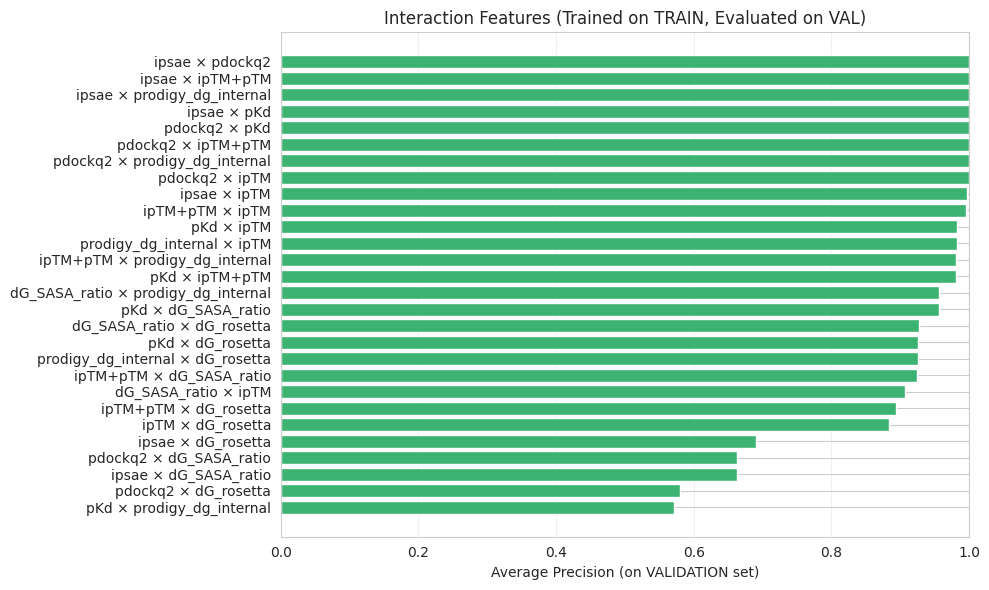

In [24]:
# Visualize top interactions
fig, ax = plt.subplots(figsize=(10, 6))

df_plot = df_interactions.sort_values("AP (VAL)", ascending=True)
ax.barh(df_plot["Interaction"], df_plot["AP (VAL)"], color="mediumseagreen")
ax.set_xlabel("Average Precision (on VALIDATION set)")
ax.set_title("Interaction Features (Trained on TRAIN, Evaluated on VAL)")
ax.set_xlim(0, 1.0)
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


# Greedy Feature Selection with Nested Cross-Validation

As in the paper (section 6, Figure 4), we implement **greedy forward selection** with **nested stratified cross-validation**.

## Paper Logic

The paper (section "Logistic regression classifier") uses:
1. **Leave-One-Group-Out (LOGO) CV externe**: each target/group is left out as test
2. **Internal greedy selection**: for each fold, build a sparse logistic model (L1 penalty) by adding features one by one
3. **Stopping criterion**: add a feature only if it improves AP by > 0.005
4. **Class imbalance handling**: `class_weight="balanced"` in LogisticRegression
5. **Normalization**: z-score per fold (fit on internal TRAIN)

## Our Implementation

- Greedy selection with iterative loop
- **Nested Cross-Validation**: StratifiedKFold externe (5 folds) for robustness
- At each iteration, test adding each candidate feature
- Metrics = average precision (AP) calculated with internal CV
- Improvement threshold: ΔAP ≥ 0.005 to add a feature
- Initial pool: all simple features + top 20 interactions
- **Difference**: StratifiedKFold (5-fold) instead of LOGO-CV (our data lacks explicit target grouping)


In [25]:
def nested_cv_score(X_train_features, y_train_labels, n_splits=5):
    """
    Evaluate features using stratified k-fold cross-validation on TRAIN set.
    Returns mean AP across folds.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    
    aps = []
    
    for train_idx, val_idx in skf.split(X_train_features, y_train_labels):
        X_tr, X_val = X_train_features[train_idx], X_train_features[val_idx]
        y_tr, y_val = y_train_labels[train_idx], y_train_labels[val_idx]
        
        # Fit scaler on inner train fold ONLY
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_val_scaled = scaler.transform(X_val)
        
        # Train logistic regression du papier
        lr = LogisticRegression(
            penalty="l1",
            solver="liblinear",
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE,
        )
        lr.fit(X_tr_scaled, y_tr)
        
        # Evaluate
        y_proba = lr.predict_proba(X_val_scaled)[:, 1]
        ap = average_precision_score(y_val, y_proba)
        aps.append(ap)
    
    return np.mean(aps), np.std(aps)


In [26]:
# Greedy forward selection: NESTED CV on TRAIN set
print("GREEDY FORWARD SELECTION (Nested CV on TRAIN)")

# Pool de toutes les features (simples + interactions) à partir de TRAIN
all_feature_names = FEATURE_COLS.copy()
all_feature_values_train = X_train.copy()
all_feature_values_val = X_val.copy()  # utilisé UNIQUEMENT en évaluation finale
all_feature_values_test = X_test.copy()  # utilisé UNIQUEMENT en évaluation finale

# Ajouter les top interactions
top_n_interactions = 20
for inter_name in df_interactions.head(top_n_interactions)["Interaction"].values:
    all_feature_names.append(inter_name)
    all_feature_values_train = np.column_stack(
        [all_feature_values_train, interaction_features_train[inter_name]]
    )
    all_feature_values_test = np.column_stack(
        [all_feature_values_test, interaction_features_test[inter_name]]
    )
    all_feature_values_val = np.column_stack(
        [all_feature_values_val, interaction_features_val[inter_name]]
    )
    
print(f"\nFeatures available: {len(all_feature_names)}")
print(f"  - Simple features: {len(FEATURE_COLS)}")
print(f"  - Top interactions: {top_n_interactions}")


GREEDY FORWARD SELECTION (Nested CV on TRAIN)

Features available: 28
  - Simple features: 8
  - Top interactions: 20


In [27]:
# Greedy selection (nested CV sur TRAIN)
selected_features = []
selected_indices = []
remaining_indices = set(range(len(all_feature_names)))

improvement_threshold = 0.005
history = []

while remaining_indices:
    # Score du modèle ACTUEL avec nested CV sur TRAIN
    if not selected_indices:
        current_ap, current_std = 0.0, 0.0
    else:
        X_temp = all_feature_values_train[:, selected_indices]
        current_ap, current_std = nested_cv_score(X_temp, y_train, n_splits=5)

    candidate_scores = []

    # On teste chaque candidate en l'ajoutant aux features déjà sélectionnées
    for idx in remaining_indices:
        current_indices = selected_indices + [idx]
        X_train_candidate = all_feature_values_train[:, current_indices]
        mean_ap, std_ap = nested_cv_score(X_train_candidate, y_train, n_splits=5)
        candidate_scores.append((idx, mean_ap, std_ap, all_feature_names[idx]))

    # Meilleur candidat (AP moyen le plus élevé)
    candidate_scores.sort(key=lambda x: x[1], reverse=True)
    best_idx, best_ap, best_std, best_name = candidate_scores[0]

    improvement = best_ap - current_ap

    print("=" * 70)
    print(f"Candidate: {best_name}")
    print(f"  → nested CV AP = {best_ap:.4f} ± {best_std:.4f}")
    print(f"  → improvement vs current = {improvement:.4f}")

    # CORRECTION: Ajouter seulement si amélioration suffisante, sinon ARRÊTER
    if improvement > improvement_threshold or len(selected_features) == 0:
        selected_features.append(best_name)
        selected_indices.append(best_idx)
        remaining_indices.remove(best_idx)
        history.append((len(selected_features), best_ap, best_std))
        print(f"✓ Feature ADDED. Total selected: {len(selected_features)}")
    else:
        # Aucune amélioration suffisante → ARRÊTER la sélection
        print(f"✗ Improvement too small (<{improvement_threshold}). STOPPING feature selection.")
        break  # Sortir de la boucle while

print("\n" + "=" * 70)

if history:
    print(f"✅ Greedy Forward Selection completed!")
    print(f"   Total features selected: {len(selected_features)}")
    print(f"   Selected features: {selected_features}")
    print(f"   Best nested CV AP on TRAIN set: {history[-1][1]:.4f} ± {history[-1][2]:.4f}")
else:
    print("No features selected by greedy forward selection.")


Candidate: pdockq2 × prodigy_dg_internal
  → nested CV AP = 0.9696 ± 0.0109
  → improvement vs current = 0.9696
✓ Feature ADDED. Total selected: 1
Candidate: prodigy_dg_internal
  → nested CV AP = 0.9736 ± 0.0084
  → improvement vs current = 0.0040
✗ Improvement too small (<0.005). STOPPING feature selection.

✅ Greedy Forward Selection completed!
   Total features selected: 1
   Selected features: ['pdockq2 × prodigy_dg_internal']
   Best nested CV AP on TRAIN set: 0.9696 ± 0.0109
Candidate: prodigy_dg_internal
  → nested CV AP = 0.9736 ± 0.0084
  → improvement vs current = 0.0040
✗ Improvement too small (<0.005). STOPPING feature selection.

✅ Greedy Forward Selection completed!
   Total features selected: 1
   Selected features: ['pdockq2 × prodigy_dg_internal']
   Best nested CV AP on TRAIN set: 0.9696 ± 0.0109


**Progression de l'AP** :
- À chaque itération, l'AP devrait augmenter (ou stagner si ΔAP < 0.005)
- L'historique montre comment le modèle se construit pas à pas

**Comparaison avec le papier** :
- Le papier rapporte les features sélectionnées et leurs coefficients (Figure 4B-C)
- Notre algorithme suit la même logique : ajout itératif jusqu'à break

# FINAL EVALUATION on TEST SET

## Paper Logic

The paper (section "Outer Loop"):
- **Leave-One-Group-Out external**: performance of selected model on test group
- **Metrics**: AP, ROC AUC, F1, precision, recall
- **Optimal threshold**: adjusted to maximize F1 on Validation data
- **Robustness**: uncertainty/variance over LOGO outer loop (multiple folds)

## Our Implementation

- TEST set never touched during selection or internal CV
- First and **only** access to TEST set here
- Train final model on TRAIN with selected features
- Normalization: StandardScaler fit on TRAIN, applied to TEST
- Full evaluation: AP, ROC AUC, F1, precision, recall, accuracy
- Optimal threshold: find threshold that maximizes F1 on VAL and apply to TEST
- Confusion matrix and detailed analysis


In [28]:
# Train final model on FULL TRAIN SET using selected features
print("\n" + "="*70)
print("FINAL MODEL EVALUATION")
print("="*70)

print(f"\n⚠️  IMPORTANT: Using TEST set for the FIRST and ONLY time now (for final metrics).")
print(f"    All feature selection was done on TRAIN+VAL only.")
print(f"    TEST set has been completely held-out until this evaluation.")

print(f"\nSelected features: {selected_features}")

# -------------------------------
# 1) Extraire les features sélectionnées pour TRAIN, VAL et TEST
# -------------------------------

# ⚠️ Il faut que all_feature_values_val existe (défini comme X_val + interactions, comme pour train/test)
X_selected_train = all_feature_values_train[:, selected_indices]
X_selected_val   = all_feature_values_val[:, selected_indices]
X_selected_test  = all_feature_values_test[:, selected_indices]

# -------------------------------
# 2) Fit du scaler sur TRAIN uniquement
# -------------------------------

scaler_final = StandardScaler()
X_selected_train_scaled = scaler_final.fit_transform(X_selected_train)
X_selected_val_scaled   = scaler_final.transform(X_selected_val)
X_selected_test_scaled  = scaler_final.transform(X_selected_test)

# -------------------------------
# 3) Entraînement du modèle final sur TRAIN
# -------------------------------

lr_final = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE,
)
lr_final.fit(X_selected_train_scaled, y_train)

# -------------------------------
# 4) Probabilités sur VAL et TEST
# -------------------------------

y_proba_val_final  = lr_final.predict_proba(X_selected_val_scaled)[:, 1]
y_proba_test_final = lr_final.predict_proba(X_selected_test_scaled)[:, 1]

# On garde une prédiction à seuil 0.5 pour TEST
y_pred_test_05 = (y_proba_test_final >= 0.5).astype(int)



FINAL MODEL EVALUATION

⚠️  IMPORTANT: Using TEST set for the FIRST and ONLY time now (for final metrics).
    All feature selection was done on TRAIN+VAL only.
    TEST set has been completely held-out until this evaluation.

Selected features: ['pdockq2 × prodigy_dg_internal']


In [29]:
# -------------------------------
# 5) Métriques principales sur TEST (seuil 0.5)
# -------------------------------

roc_auc_test = roc_auc_score(y_test, y_proba_test_final)
ap_test = average_precision_score(y_test, y_proba_test_final)
f1_test_05 = f1_score(y_test, y_pred_test_05, zero_division=0)
precision_test_05 = precision_score(y_test, y_pred_test_05, zero_division=0)
recall_test_05 = recall_score(y_test, y_pred_test_05, zero_division=0)
accuracy_test_05 = accuracy_score(y_test, y_pred_test_05)

print(f"\n=== TEST SET PERFORMANCE (threshold = 0.50) ===")
print(f"ROC AUC:           {roc_auc_test:.4f}")
print(f"Average Precision: {ap_test:.4f}")
print(f"F1-score:          {f1_test_05:.4f}")
print(f"Precision:         {precision_test_05:.4f}")
print(f"Recall:            {recall_test_05:.4f}")
print(f"Accuracy:          {accuracy_test_05:.4f}")

print(f"\n=== Classification Report (TEST, threshold = 0.50) ===")
print(classification_report(y_test, y_pred_test_05, target_names=["Non-binder", "Binder"]))


=== TEST SET PERFORMANCE (threshold = 0.50) ===
ROC AUC:           0.9872
Average Precision: 0.9894
F1-score:          0.9600
Precision:         1.0000
Recall:            0.9231
Accuracy:          0.9620

=== Classification Report (TEST, threshold = 0.50) ===
              precision    recall  f1-score   support

  Non-binder       0.93      1.00      0.96        40
      Binder       1.00      0.92      0.96        39

    accuracy                           0.96        79
   macro avg       0.97      0.96      0.96        79
weighted avg       0.96      0.96      0.96        79



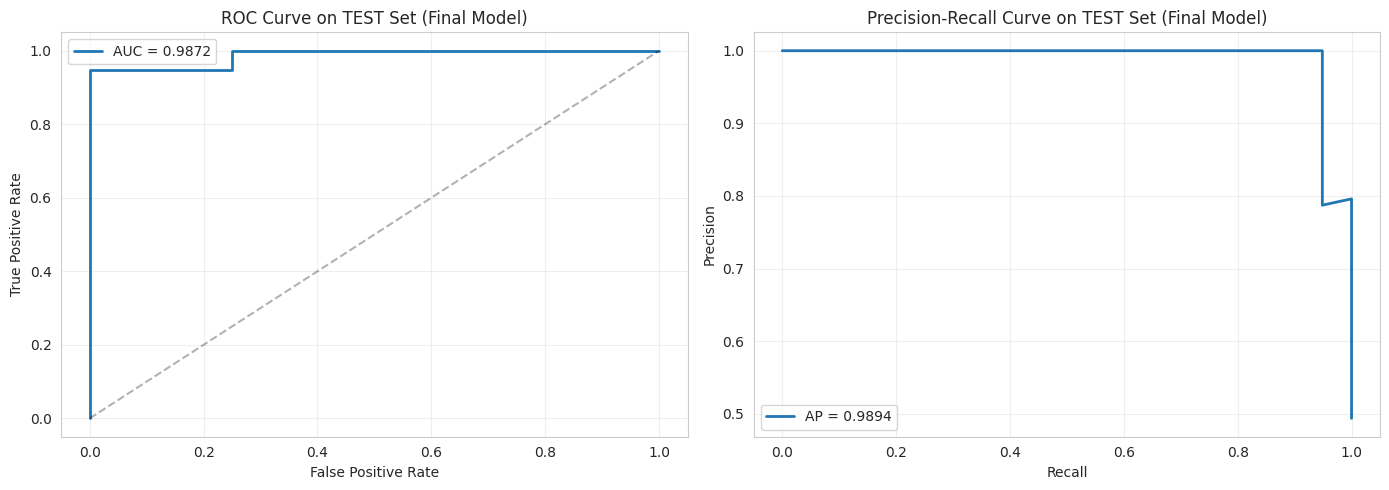

✅ ROC and PR curves on TEST set


In [30]:
# Visualize ROC and PR curves on TEST set
fpr_test, tpr_test, _ = roc_curve(y_test, y_proba_test_final)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba_test_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
auc_test = roc_auc_score(y_test, y_proba_test_final)
axes[0].plot(fpr_test, tpr_test, linewidth=2, label=f"AUC = {auc_test:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve on TEST Set (Final Model)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# PR
ap_test = average_precision_score(y_test, y_proba_test_final)
axes[1].plot(recall_curve, precision_curve, linewidth=2, label=f"AP = {ap_test:.4f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve on TEST Set (Final Model)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ ROC and PR curves on TEST set")


#### Explication des courbes ROC et Precision-Recall

**Panneau gauche (ROC Curve)** :
- X = Taux de faux positifs (FP / N_neg)
- Y = Taux de vrais positifs (TP / N_pos)
- Diagonale = classifier aléatoire (AUC = 0.5)
- Courbe en haut-gauche = bon classifier (AUC proche de 1.0)
- **AUC** = probabilité qu'un vrai binder soit ranké plus haut qu'un non-binder aléatoire

**Panneau droit (Precision-Recall Curve)** :
- X = Recall = TP / (TP + FN) = "parmi les vrais binders, combien on retrouve"
- Y = Precision = TP / (TP + FP) = "parmi nos prédictions positives, combien sont correctes"
- **AP** (Average Precision) = aire sous cette courbe
- Plus robuste que ROC-AUC quand les classes sont déséquilibrées (~88% négatifs, 12% positifs dans l'étude)

**Comparaison avec le papier** : Figure 4A montre des PR curves similaires pour le meilleur modèle greedy. Notre courbe devrait avoir une forme comparable.

In [31]:
print("BOOTSTRAP ON TEST SET (fixed model, threshold = 0.5)")
print("="*70)

n_boot = 1000
rng = np.random.default_rng(RANDOM_STATE)

auc_boot  = []
ap_boot   = []
prec_boot = []
rec_boot  = []
f1_boot   = []
acc_boot  = []

roc_points = []   # pour éventuellement tracer des bandes ROC plus tard
pr_points  = []   # idem pour PR

for _ in range(n_boot):
    # Bootstrap indices sur TEST
    idx = rng.integers(0, len(y_test), len(y_test))
    y_test_bs = y_test[idx]
    y_proba_bs = y_proba_test_final[idx]
    
    # Scores continus
    auc_boot.append(roc_auc_score(y_test_bs, y_proba_bs))
    ap_boot.append(average_precision_score(y_test_bs, y_proba_bs))
    
    # Prédictions binaires à seuil 0.5 (même seuil que plus haut)
    y_pred_bs = (y_proba_bs >= 0.5).astype(int)
    
    prec_boot.append(precision_score(y_test_bs, y_pred_bs, zero_division=0))
    rec_boot.append(recall_score(y_test_bs, y_pred_bs, zero_division=0))
    f1_boot.append(f1_score(y_test_bs, y_pred_bs, zero_division=0))
    acc_boot.append(accuracy_score(y_test_bs, y_pred_bs))
    
    # Stocker les courbes pour éventuellement faire des bandes d'IC
    fpr_bs, tpr_bs, _ = roc_curve(y_test_bs, y_proba_bs)
    roc_points.append((fpr_bs, tpr_bs))
    
    prec_bs, rec_bs, _ = precision_recall_curve(y_test_bs, y_proba_bs)
    pr_points.append((rec_bs, prec_bs))

def ci95(arr):
    return np.percentile(arr, [2.5, 97.5])

print("\n--- Scalar metrics with 95% bootstrap CIs (TEST set) ---")
print(f"AUC        point = {roc_auc_test:.4f},  CI95 = [{ci95(auc_boot)[0]:.4f}, {ci95(auc_boot)[1]:.4f}]")
print(f"AP         point = {ap_test:.4f},       CI95 = [{ci95(ap_boot)[0]:.4f}, {ci95(ap_boot)[1]:.4f}]")
print(f"Precision  point = {precision_test_05:.4f}, CI95 = [{ci95(prec_boot)[0]:.4f}, {ci95(prec_boot)[1]:.4f}]")
print(f"Recall     point = {recall_test_05:.4f},    CI95 = [{ci95(rec_boot)[0]:.4f}, {ci95(rec_boot)[1]:.4f}]")
print(f"F1         point = {f1_test_05:.4f},        CI95 = [{ci95(f1_boot)[0]:.4f}, {ci95(f1_boot)[1]:.4f}]")
print(f"Accuracy   point = {accuracy_test_05:.4f},  CI95 = [{ci95(acc_boot)[0]:.4f}, {ci95(acc_boot)[1]:.4f}]")


BOOTSTRAP ON TEST SET (fixed model, threshold = 0.5)



--- Scalar metrics with 95% bootstrap CIs (TEST set) ---
AUC        point = 0.9872,  CI95 = [0.9612, 1.0000]
AP         point = 0.9894,       CI95 = [0.9684, 1.0000]
Precision  point = 1.0000, CI95 = [1.0000, 1.0000]
Recall     point = 0.9231,    CI95 = [0.8293, 1.0000]
F1         point = 0.9600,        CI95 = [0.9067, 1.0000]
Accuracy   point = 0.9620,  CI95 = [0.9114, 1.0000]


In [32]:
auc_ci  = ci95(auc_boot)
ap_ci   = ci95(ap_boot)

print("\n=== BOOTSTRAP (TEST set) — Summary ===")
print(f"AUC  point estimate : {roc_auc_test:.4f}")
print(f"AUC  95% CI         : [{auc_ci[0]:.4f}, {auc_ci[1]:.4f}]")

print(f"\nAP   point estimate : {ap_test:.4f}")
print(f"AP   95% CI         : [{ap_ci[0]:.4f}, {ap_ci[1]:.4f}]")



=== BOOTSTRAP (TEST set) — Summary ===
AUC  point estimate : 0.9872
AUC  95% CI         : [0.9612, 1.0000]

AP   point estimate : 0.9894
AP   95% CI         : [0.9684, 1.0000]


In [33]:
# Grille uniforme pour ROC
fpr_grid = np.linspace(0, 1, 200)
tpr_boot_interp = []

for fpr_bs, tpr_bs in roc_points:
    tpr_interp = np.interp(fpr_grid, fpr_bs, tpr_bs)
    tpr_boot_interp.append(tpr_interp)

tpr_boot_interp = np.array(tpr_boot_interp)

tpr_mean = tpr_boot_interp.mean(axis=0)
tpr_ci_low, tpr_ci_high = np.percentile(tpr_boot_interp, [2.5, 97.5], axis=0)


In [34]:
# Grille uniforme pour PR
rec_grid = np.linspace(0, 1, 200)
prec_boot_interp = []

for rec_bs, prec_bs in pr_points:
    prec_interp = np.interp(rec_grid, rec_bs[::-1], prec_bs[::-1])  # il faut inverser
    prec_boot_interp.append(prec_interp)

prec_boot_interp = np.array(prec_boot_interp)

prec_mean = prec_boot_interp.mean(axis=0)
prec_ci_low, prec_ci_high = np.percentile(prec_boot_interp, [2.5, 97.5], axis=0)


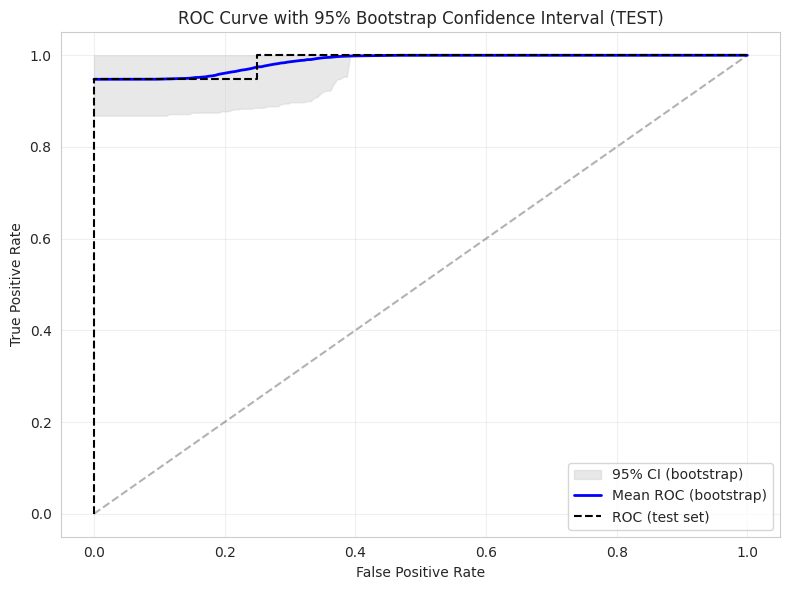

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))

# Bande IC 95%
ax.fill_between(fpr_grid, tpr_ci_low, tpr_ci_high,
                color="lightgray", alpha=0.5, label="95% CI (bootstrap)")

# Courbe moyenne bootstrap
ax.plot(fpr_grid, tpr_mean, color="blue", linewidth=2, label="Mean ROC (bootstrap)")

# Courbe réelle
ax.plot(fpr_test, tpr_test, color="black", linestyle="--", label="ROC (test set)")

ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve with 95% Bootstrap Confidence Interval (TEST)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


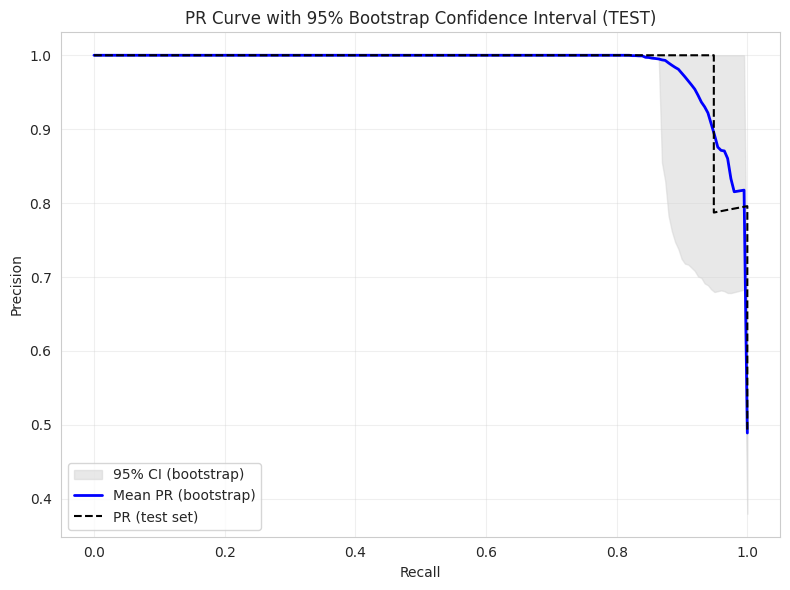

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.fill_between(rec_grid, prec_ci_low, prec_ci_high,
                color="lightgray", alpha=0.5, label="95% CI (bootstrap)")

ax.plot(rec_grid, prec_mean, color="blue", linewidth=2, label="Mean PR (bootstrap)")

axes_pr = plt.gca()
axes_pr.plot(recall_curve, precision_curve, color="black", linestyle="--", 
             label="PR (test set)")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("PR Curve with 95% Bootstrap Confidence Interval (TEST)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



THRESHOLD OPTIMIZATION (Using VALIDATION set only)



Optimal threshold selected on VALIDATION = 0.341
F1-score on VALIDATION at optimal threshold = 1.0000

=== Performance on TEST set with VALIDATION-optimized threshold ===
Threshold used: 0.341
Precision: 1.0000
Recall:    0.9487
F1-score:  0.9737


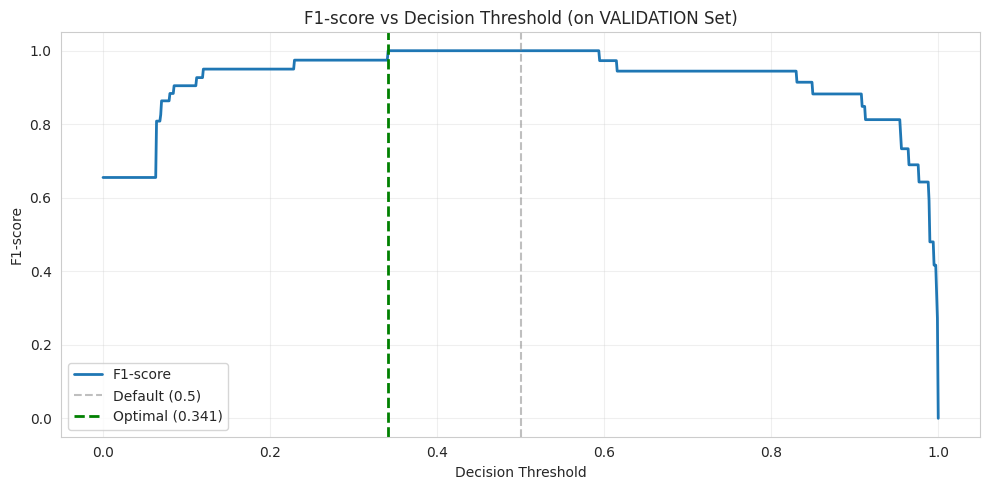

In [37]:
# Threshold vs F1-score on VAL set# Find optimal threshold (maximizing F1 on VALIDATION set)
from sklearn.metrics import f1_score

print("\n" + "="*70)
print("THRESHOLD OPTIMIZATION (Using VALIDATION set only)")

thresholds = np.linspace(0, 1, 1000)

# F1-score evaluated ONLY on VALIDATION
f1_scores_val = [
    f1_score(y_val, (y_proba_val_final >= t).astype(int), zero_division=0)
    for t in thresholds
]

optimal_threshold = thresholds[np.argmax(f1_scores_val)]
optimal_f1_val = np.max(f1_scores_val)

print(f"\nOptimal threshold selected on VALIDATION = {optimal_threshold:.3f}")
print(f"F1-score on VALIDATION at optimal threshold = {optimal_f1_val:.4f}")

# Apply this threshold ONCE to the TEST predictions
y_pred_opt_test = (y_proba_test_final >= optimal_threshold).astype(int)

# Metrics on TEST using this VAL-optimized threshold
precision_opt_test = precision_score(y_test, y_pred_opt_test, zero_division=0)
recall_opt_test = recall_score(y_test, y_pred_opt_test, zero_division=0)
f1_opt_test = f1_score(y_test, y_pred_opt_test, zero_division=0)

print("\n=== Performance on TEST set with VALIDATION-optimized threshold ===")
print(f"Threshold used: {optimal_threshold:.3f}")
print(f"Precision: {precision_opt_test:.4f}")
print(f"Recall:    {recall_opt_test:.4f}")
print(f"F1-score:  {f1_opt_test:.4f}")


fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(thresholds, f1_scores_val, label='F1-score', linewidth=2)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.5)')
ax.axvline(optimal_threshold, color='green', linestyle='--', linewidth=2, label=f'Optimal ({optimal_threshold:.3f})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('F1-score')
ax.set_title('F1-score vs Decision Threshold (on VALIDATION Set)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



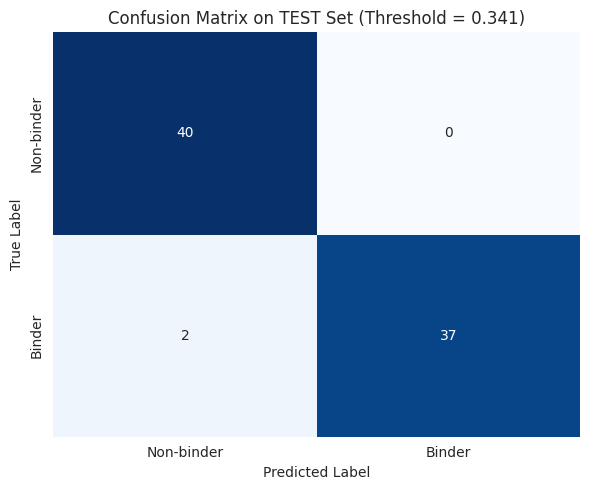


Confusion Matrix on TEST Set:
True Negatives:  40 (correctly identified non-binders)
False Positives: 0 (false alarms - non-binders predicted as binders)
False Negatives: 2 (missed binders)
True Positives:  37 (correctly identified binders)

Specificity: 1.0000 (ability to reject non-binders)
Sensitivity: 0.9487 (ability to identify binders)


In [38]:
# Confusion matrix on TEST set
cm_test = confusion_matrix(y_test, y_pred_opt_test)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-binder', 'Binder'],
            yticklabels=['Non-binder', 'Binder'])
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title(f'Confusion Matrix on TEST Set (Threshold = {optimal_threshold:.3f})')

plt.tight_layout()
plt.show()

# Interpretation
tn, fp, fn, tp = cm_test.ravel()
print(f"\nConfusion Matrix on TEST Set:")
print(f"True Negatives:  {tn} (correctly identified non-binders)")
print(f"False Positives: {fp} (false alarms - non-binders predicted as binders)")
print(f"False Negatives: {fn} (missed binders)")
print(f"True Positives:  {tp} (correctly identified binders)")
print(f"\nSpecificity: {tn/(tn+fp):.4f} (ability to reject non-binders)")
print(f"Sensitivity: {tp/(tp+fn):.4f} (ability to identify binders)")



DISTRIBUTION OF SELECTED FEATURES

Selected features:
  - Simple features: []
  - Interaction features: ['pdockq2 × prodigy_dg_internal']


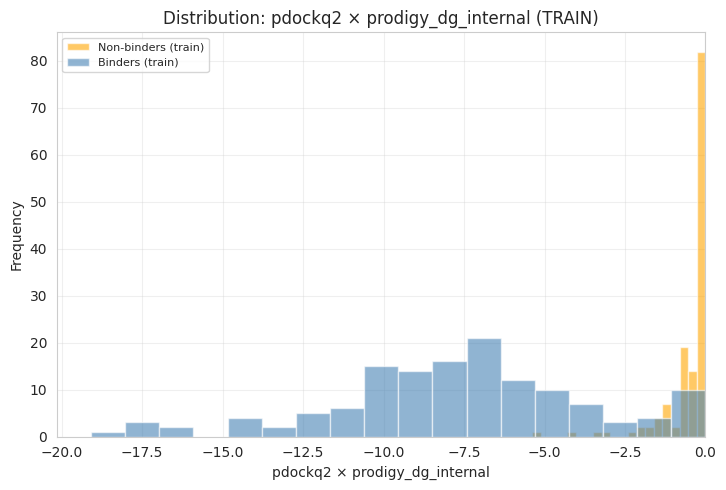


✅ Distributions plotted for 1 selected features on TRAIN set


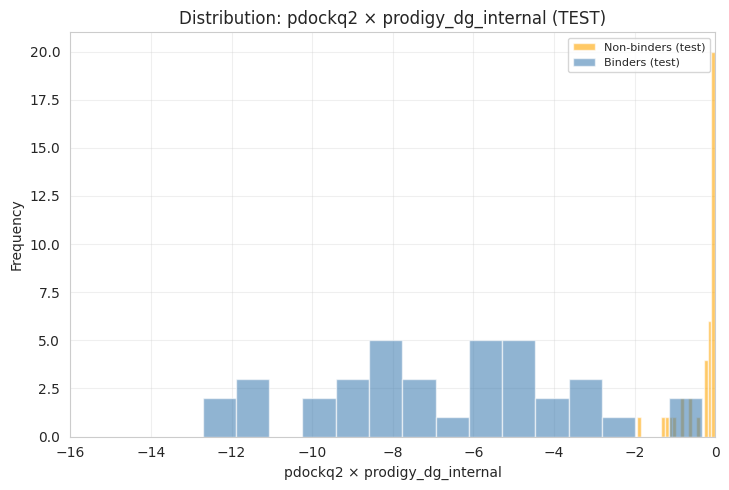

✅ Distributions plotted for 1 selected features on TEST set


In [43]:
# Plot distributions of selected features (after greedy selection)
print("\n" + "="*70)
print("DISTRIBUTION OF SELECTED FEATURES")

# On regroupe les features sélectionnées en simples et interactions
selected_simple = [f for f in selected_features if f in FEATURE_COLS]
selected_interactions = [f for f in selected_features if f not in FEATURE_COLS]

print(f"\nSelected features:")
print(f"  - Simple features: {selected_simple}")
print(f"  - Interaction features: {selected_interactions}")

# Préparer les données pour les plots
n_selected_features = len(selected_features)

if n_selected_features > 0:
    # Créer un dictionnaire pour accéder facilement aux valeurs d'interactions
    interaction_dict_train = {}
    interaction_dict_val = {}
    interaction_dict_test = {}
    
    for idx, inter_name in enumerate(selected_interactions):
        interaction_dict_train[inter_name] = interaction_features_train[inter_name]
        interaction_dict_val[inter_name] = interaction_features_val[inter_name]
        interaction_dict_test[inter_name] = interaction_features_test[inter_name]
    
    # ========== PLOT TRAIN SET ==========
    n_cols = 2
    n_rows = int(np.ceil(n_selected_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
    axes = axes.ravel()
    
    for ax_idx, feature_name in enumerate(selected_features):
        ax = axes[ax_idx]
        
        # Récupérer les valeurs selon le type de feature
        if feature_name in FEATURE_COLS:
            # Feature simple
            feature_idx = FEATURE_COLS.index(feature_name)
            train_pos = df_train[df_train["label"]==1][feature_name].dropna()
            train_neg = df_train[df_train["label"]==0][feature_name].dropna()
            plot_label = feature_name
        else:
            # Feature interaction
            train_pos = interaction_dict_train[feature_name][y_train == 1]
            train_neg = interaction_dict_train[feature_name][y_train == 0]
            plot_label = feature_name
        
        # Plot histograms
        ax.hist(train_neg, bins=20, alpha=0.6, label='Non-binders (train)', color='orange')
        ax.hist(train_pos, bins=20, alpha=0.6, label='Binders (train)', color='steelblue')
        
        ax.set_xlabel(plot_label)
        ax.set_ylabel('Frequency')
        ax.set_title(f'Distribution: {plot_label} (TRAIN)')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        
        # Centrer sur les données
        if feature_name in FEATURE_COLS:
            y_min = min(train_pos.min(), train_neg.min())
            y_max = max(train_pos.max(), train_neg.max())
        else:
            y_min = min(train_pos.min(), train_neg.min())
            y_max = max(train_pos.max(), train_neg.max())
        
        y_range = y_max - y_min
        if y_range > 0:
            ax.set_xlim([y_min * 0.95, y_max * 1.05])
    
    # Supprimer les axes non utilisés
    for j in range(len(selected_features), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Distributions plotted for {len(selected_features)} selected features on TRAIN set")
    
    # ========== PLOT TEST SET ==========
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
    axes = axes.ravel()
    
    for ax_idx, feature_name in enumerate(selected_features):
        ax = axes[ax_idx]
        
        # Récupérer les valeurs selon le type de feature
        if feature_name in FEATURE_COLS:
            # Feature simple
            feature_idx = FEATURE_COLS.index(feature_name)
            test_pos = df_test[df_test["label"]==1][feature_name].dropna()
            test_neg = df_test[df_test["label"]==0][feature_name].dropna()
            plot_label = feature_name
        else:
            # Feature interaction
            test_pos = interaction_dict_test[feature_name][y_test == 1]
            test_neg = interaction_dict_test[feature_name][y_test == 0]
            plot_label = feature_name
        
        # Plot histograms
        ax.hist(test_neg, bins=20, alpha=0.6, label='Non-binders (test)', color='orange')
        ax.hist(test_pos, bins=20, alpha=0.6, label='Binders (test)', color='steelblue')
        
        ax.set_xlabel(plot_label)
        ax.set_ylabel('Frequency')
        ax.set_title(f'Distribution: {plot_label} (TEST)')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        
        # Centrer sur les données
        if feature_name in FEATURE_COLS:
            y_min = min(test_pos.min(), test_neg.min())
            y_max = max(test_pos.max(), test_neg.max())
        else:
            y_min = min(test_pos.min(), test_neg.min())
            y_max = max(test_pos.max(), test_neg.max())
        
        y_range = y_max - y_min
        if y_range > 0:
            ax.set_xlim([y_min * 0.95, y_max * 1.05])
    
    # Supprimer les axes non utilisés
    for j in range(len(selected_features), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Distributions plotted for {len(selected_features)} selected features on TEST set")
else:
    print("⚠️  No features selected by greedy selection")

In [44]:
# Analyse complète des binders mal classés avec leurs identifiants et métriques initiales
print("\n" + "="*80)
print("ANALYSIS OF MISCLASSIFIED BINDERS (False Negatives)")
print("="*80)

# Identifier les false negatives : y_true = 1 (binder) mais y_pred = 0 (non-binder)
fn_mask = (y_test == 1) & (y_pred_opt_test == 0)
fn_indices = np.where(fn_mask)[0]

print(f"\n📊 Total False Negatives (missed binders): {len(fn_indices)}")
print(f"    These are TRUE binders that the model incorrectly predicted as non-binders")
print(f"    Decision threshold used: {optimal_threshold:.4f}\n")

if len(fn_indices) > 0:
    # Récupérer les indices originaux dans le dataset complet
    test_indices_in_df_clean = test_indices
    
    # Créer un dataframe avec toutes les informations
    fn_data = []
    
    for idx, fn_idx in enumerate(fn_indices):
        # Index original dans df_clean
        original_idx = test_indices_in_df_clean[fn_idx]
        
        # Récupérer les données originales complètes
        original_row = df_clean.iloc[original_idx]
        
        # Probabilité prédite
        prob_binder = y_proba_test_final[fn_idx]
        
        # Construire le dictionnaire avec toutes les infos
        fn_info = {
            "FN_Number": idx + 1,
            "Test_Index": fn_idx,
            "Dataset_Index": original_idx,
            "Protein_ID": original_row.get('id', 'N/A'),
            "True_Label": "BINDER",
            "Predicted_Label": "NON-BINDER",
            "Pred_Prob_Binder": prob_binder,
            "Pred_Prob_NonBinder": 1 - prob_binder,
            "Distance_to_Threshold": optimal_threshold - prob_binder,
        }
        
        # Ajouter toutes les métriques du dataset original
        for feat in FEATURE_COLS:
            fn_info[f"Metric_{feat}"] = original_row[feat]
        
        # Ajouter les features d'interaction sélectionnées
        for inter_name in selected_interactions:
            fn_info[f"Interaction_{inter_name}"] = interaction_features_test[inter_name][fn_idx]
        
        fn_data.append(fn_info)
    
    df_fn = pd.DataFrame(fn_data)
    
    # Affichage détaillé
    print("="*80)
    print("DETAILED LIST OF MISCLASSIFIED BINDERS")
    print("="*80)
    
    for _, row in df_fn.iterrows():
        print(f"\n{'='*80}")
        print(f"🔴 False Negative #{int(row['FN_Number'])}")
        print(f"{'='*80}")
        print(f"  Protein Complex ID:        {row['Protein_ID']}")
        print(f"  Dataset Index:             {int(row['Dataset_Index'])}")
        print(f"  Test Set Index:            {int(row['Test_Index'])}")
        print(f"\n  Classification:")
        print(f"    ✓ True Label:            {row['True_Label']}")
        print(f"    ✗ Predicted Label:       {row['Predicted_Label']} ❌")
        print(f"    • Model Probability:     {row['Pred_Prob_Binder']:.4f} (Binder) | {row['Pred_Prob_NonBinder']:.4f} (Non-Binder)")
        print(f"    • Decision Threshold:    {optimal_threshold:.4f}")
        print(f"    • Distance to Threshold: {row['Distance_to_Threshold']:+.4f} (needed {abs(row['Distance_to_Threshold']):.4f} more)")
        
        print(f"\n  Original Metric Values:")
        for feat in FEATURE_COLS:
            metric_key = f"Metric_{feat}"
            print(f"    • {feat:25s}: {row[metric_key]:10.6f}")
        
        if selected_interactions:
            print(f"\n  Interaction Features (Selected):")
            for inter_name in selected_interactions:
                inter_key = f"Interaction_{inter_name}"
                print(f"    • {inter_name:25s}: {row[inter_key]:10.6f}")
    
    # Statistiques récapitulatives
    print(f"\n\n{'='*80}")
    print("SUMMARY STATISTICS FOR MISCLASSIFIED BINDERS")
    print("="*80)
    
    print("\n📉 Prediction Confidence Statistics:")
    print(f"  • Mean P(Binder):              {df_fn['Pred_Prob_Binder'].mean():.4f} ± {df_fn['Pred_Prob_Binder'].std():.4f}")
    print(f"  • Min P(Binder):               {df_fn['Pred_Prob_Binder'].min():.4f}")
    print(f"  • Max P(Binder):               {df_fn['Pred_Prob_Binder'].max():.4f}")
    print(f"  • Median P(Binder):            {df_fn['Pred_Prob_Binder'].median():.4f}")
    print(f"  • Mean distance to threshold:  {df_fn['Distance_to_Threshold'].mean():.4f}")
    
    print("\n📊 Metric Comparison: False Negatives vs All True Binders")
    print("   (Negative diff = FN has lower values than average binder)")
    print("-"*80)
    
    all_binders_mask = y_test == 1
    
    for feat in FEATURE_COLS:
        fn_mean = df_fn[f"Metric_{feat}"].mean()
        fn_std = df_fn[f"Metric_{feat}"].std()
        all_mean = df_test[df_test['label'] == 1][feat].mean()
        all_std = df_test[df_test['label'] == 1][feat].std()
        diff = fn_mean - all_mean
        
        arrow = "↓" if diff < 0 else "↑" if diff > 0 else "="
        print(f"  {feat:25s} │ FN: {fn_mean:8.4f} ± {fn_std:6.4f} │ All: {all_mean:8.4f} ± {all_std:6.4f} │ Δ: {diff:+8.4f} {arrow}")
    
    if selected_interactions:
        print("\n  Selected Interaction Features:")
        print("-"*80)
        for inter_name in selected_interactions:
            fn_mean = df_fn[f"Interaction_{inter_name}"].mean()
            fn_std = df_fn[f"Interaction_{inter_name}"].std()
            all_inter_vals = interaction_features_test[inter_name][all_binders_mask]
            all_mean = all_inter_vals.mean()
            all_std = all_inter_vals.std()
            diff = fn_mean - all_mean
            
            arrow = "↓" if diff < 0 else "↑" if diff > 0 else "="
            print(f"  {inter_name:25s} │ FN: {fn_mean:8.4f} ± {fn_std:6.4f} │ All: {all_mean:8.4f} ± {all_std:6.4f} │ Δ: {diff:+8.4f} {arrow}")
    
    # Export to CSV option
    print("\n\n💾 To save this analysis to CSV, uncomment and run:")
    print(f"   # df_fn.to_csv('false_negatives_analysis.csv', index=False)")
    print(f"   # print('✅ Saved {len(df_fn)} misclassified binders to false_negatives_analysis.csv')")
    
else:
    print("\n✅ PERFECT CLASSIFICATION! No false negatives detected.")
    print("   The model correctly identified all true binders in the test set.")


ANALYSIS OF MISCLASSIFIED BINDERS (False Negatives)

📊 Total False Negatives (missed binders): 2
    These are TRUE binders that the model incorrectly predicted as non-binders
    Decision threshold used: 0.3413

DETAILED LIST OF MISCLASSIFIED BINDERS

🔴 False Negative #1
  Protein Complex ID:        8b3s__A1_O31597_and_8b3s__B1_A0A164W157
  Dataset Index:             91
  Test Set Index:            15

  Classification:
    ✓ True Label:            BINDER
    ✗ Predicted Label:       NON-BINDER ❌
    • Model Probability:     0.0941 (Binder) | 0.9059 (Non-Binder)
    • Decision Threshold:    0.3413
    • Distance to Threshold: +0.2473 (needed 0.2473 more)

  Original Metric Values:
    • ipsae                    :   0.011076
    • pdockq2                  :   0.030500
    • pKd                      :  10.330797
    • ipTM+pTM                 :   0.253257
    • dG_SASA_ratio            :   6.520787
    • prodigy_dg_internal      : -14.097169
    • ipTM                     :   0.203716
